In [1]:
import json
import re

In [2]:
text = """

 Video
Glendale, AZ
September 20, 2025
 View Transcript
Speech: Donald Trump Addresses a Memorial for Charlie Kirk in Glendale, Arizona - September 21, 2025

 Video
Mount Vernon, VA
September 19, 2025
 View Transcript
Speech: Donald Trump Addresses the American Cornerstone Institute Dinner - September 20, 2025

 Video
Washington, DC
September 7, 2025
 View Transcript
Speech: Donald Trump Addresses the Religious Liberty Commission in Washington - September 8, 2025

 Video
La Crosse, WI
August 27, 2025
 View Transcript
Speech: JD Vance Discusses the Economy in La Crosse, Wisconsin - August 28, 2025

 Video
Peachtree City, GA
August 20, 2025
 View Transcript
Speech: JD Vance Promotes GOP Economic Policies in Peachtree City, Georgia - August 21, 2025

 Video
Canton, OH
July 27, 2025
 View Transcript
Speech: JD Vance Promotes Administration Policies in Canton, Ohio - July 28, 2025

 Video
Washington, DC
July 22, 2025
 View Transcript
Speech: Donald Trump Delivers an AI Policy Speech and Signs Executive Orders - July 23, 2025

 Video
Washington, DC
July 21, 2025
 View Transcript
Speech: Donald Trump Hosts a White House Reception for GOP Congressmembers - July 22, 2025

 Video
Washington, DC
July 17, 2025
 View Transcript
Speech: Donald Trump Signs Crypto Stablecoin Legislation Into Law - July 18, 2025

 Video
Washington, DC
July 13, 2025
 View Transcript
Speech: Donald Trump Attends a White House Faith Office Luncheon - July 14, 2025

 Video
Des Moines, IA
July 2, 2025
 View Transcript
Speech: Donald Trump Delivers a Salute to America Speech in Des Moines, Iowa - July 3, 2025

 Video
Washington, DC
June 25, 2025
 View Transcript
Speech: Donald Trump Hosts a Political Event in Support of His Budget - June 26, 2025

 Video
Lima, OH
June 23, 2025
 View Transcript
Speech: JD Vance Delivers the Keynote Address at the Ohio GOP Dinner in Lima - June 24, 2025

 Video
Washington, DC
June 11, 2025
 View Transcript
Speech: Donald Trump Signs a Bill Blocking Bans on Gas-Powered Cars - June 12, 2025

 Video
Fort Liberty, NC
June 9, 2025
 View Transcript
Speech: Donald Trump Speaks at the 250th Anniversary of the Army at Fort Liberty - June 10, 2025

 Video
Washington, DC
May 29, 2025
 View Transcript
Speech: Donald Trump Delivers a Speech About the U.S. Steel Deal in Pennsylvania - May 30, 2025

 Video
Washington, DC
May 23, 2025
 View Transcript
Speech: Donald Trump Delivers the Commencement Address at West Point - May 24, 2025

 Video
Washington, DC
May 18, 2025
 View Transcript
Speech: Donald Trump Attends a Kennedy Center Board Meeting - May 19, 2025

 Video
Al Udeid Air Base, Qatar
May 14, 2025
 View Transcript
Speech: Donald Trump Address U.S. Service Personnel at Al Udeid Air Base in Qatar - May 15, 2025

 Video
Riyadh, Saudi Arabia
May 12, 2025
 View Transcript
Speech: Donald Trump Addresses a U.S.-Saudi Investment Event in Riyadh, Saudi Arabia - May 13, 2025

 Video
Washington, DC
May 6, 2025
 View Transcript
Speech: JD Vance Addresses the Munich Leaders Conference in Germany - May 7, 2025

 Video
Tuscaloosa, AL
April 30, 2025
 View Transcript
Speech: Donald Trump Delivers the Commencement Address at the University of Alabama - May 1, 2025

 Video
Warren, MI
April 28, 2025
 View Transcript
Speech: Donald Trump Holds a Political Rally in Warren, Michigan - April 29, 2025.

 Video
Washington, DC
April 7, 2025
 View Transcript
Speech: Donald Trump Signs Executive Orders to Promote Coal Production - April 8, 2025

 Video
Washington, DC
April 7, 2025
 View Transcript
Speech: Donald Trump Addresses an Republican Dinner in Washington - April 8, 2025

 Video
Washington, DC
April 1, 2025
 View Transcript
Speech: Donald Trump Announces New Tariffs at a Rose Garden Event - April 2, 2025

 Video
Washington, DC
March 13, 2025
 View Transcript
Speech: Donald Trump Addresses the Staff at the Department of Justice - March 14, 2025

 Video
Washington, DC
March 3, 2025
 View Transcript
Speech: Donald Trump Addresses a Joint Session of Congress at the U.S. Capitol - March 4, 2025

 Video
National Harbor, MD
February 21, 2025
 View Transcript
Speech: Donald Trump Delivers a Speech at the 2025 CPAC Convention in Maryland - February 22, 2025

 Video
Washington, DC
February 20, 2025
 View Transcript
Speech: Donald Trump Addresses the Nation's Governors at The White House - February 21, 2025

 Video
Washington, DC
February 19, 2025
 View Transcript
Speech: Donald Trump Addresses a Republican Governors Dinner in Washington - February 20, 2025

 Video
Miami Beach, FL
February 18, 2025
 View Transcript
Speech: Donald Trump Addresses the FII Priority Conference in Miami Beach, Florida - February 19, 2025

 Video
Palm Beach, FL
February 6, 2025
 View Transcript
Speech: Donald Trump Addresses GOP Senators at Dinner at Mar-a-Lago - February 7, 2025

 Video
Washington, DC
February 5, 2025
 View Transcript
Speech: Donald Trump Attends the National Prayer Breakfast at The Capitol - February 6, 2025

 Video
Miami, FL
January 26, 2025
 View Transcript
Speech: Donald Trump Addresses the House GOP Issues Conference in Miami - January 27, 2025

 Video
Las Vegas, NV
January 24, 2025
 View Transcript
Speech: Donald Trump Holds a Political Rally in Las Vegas - January 25, 2025

 Video
Washington, DC
January 22, 2025
 View Transcript
Speech: Donald Trump Delivers Remarks Via Video at the World Economic Forum - January 23, 2025

 Video
Washington, DC
January 19, 2025
 View Transcript
Speech: Donald Trump Delivers His Inaugural Address at the U.S. Capitol - January 20, 2025

 Video
Washington, DC
January 19, 2025
 View Transcript
Speech: Donald Trump Addresses Attendees in Advance of the Inaugural Lunch - January 20, 2025

 Video
Washington, DC
January 19, 2025
 View Transcript
Speech: Donald Trump Holds a Post-Inaugural Rally at Capitol One Arena - January 20, 2025

 Video
Washington, DC
January 18, 2025
 View Transcript
Speech: Donald Trump Holds a Political Rally in Washington - January 19, 2025

 Video
Phoenix, AZ
December 21, 2024
 View Transcript
Speech: Donald Trump Addresses a Turning Point USA Political Rally in Phoenix - December 22, 2024

 Video
Reading, PA
November 3, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Reading, Pennsylvania - November 4, 2024

 Video
Raleigh, NC
November 3, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Raleigh, North Carolina - November 4, 2024

 Video
Grand Rapids, MI
November 3, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Grand Rapids, Michigan - November 4, 2024

 Video
Pittsburgh, PA
November 3, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Pittsburgh - November 4, 2024

 Video
Macon, GA
November 2, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Macon, Georgia - November 3, 2024

 Video
Lititz, PA
November 2, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Lititz, Pennsylvania - November 3, 2024

 Video
Kinston, NC
November 2, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Kinston, North Carolina - November 3, 2024

 Video
Salem, VA
November 1, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Salem, Virginia - November 2, 2024

 Video
Gastonia, NC
November 1, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Gastonia, North Carolina - November 2, 2024

 Video
Greensboro, NC
November 1, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Greensboro, North Carolina - November 2, 2024

 Video
Warren, MI
October 31, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Warren, Michigan - November 1, 2024

 Video
Milwaukee, WI
October 31, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Milwaukee, Wisconsin - November 1, 2024

 Video
Albuquerque, NM
October 30, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Albuquerque, New Mexico - October 31, 2024

 Video
Henderson, NV
October 30, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Henderson, Nevada - October 31, 2024

 Video
Rocky Mount, NC
October 29, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Rocky Mount, North Carolina - October 30, 2024

 Video
Green Bay, WI
October 29, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Green Bay, Wisconsin - October 30, 2024

 Video
Allentown, PA
October 28, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Allentown, Pennsylvania - October 29, 2024

 Video
Atlanta, GA
October 27, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Atlanta - October 28, 2024

 Video
New York, NY
October 26, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in New York City - October 27, 2024

 Video
State College, PA
October 25, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in State College, Pennsylvania - October 26, 2024

 Video
Novi, MI
October 25, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Novi, Michigan - October 26, 2024

 Video
Traverse City, MI
October 24, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Traverse City, Michigan - October 25, 2024

 Video
Austin, TX
October 24, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Event on Immigration in Austin, Texas - October 25, 2024

 Video
Tempe, AZ
October 23, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Tempe, Arizona - October 24, 2024

 Video
Las Vegas, NV
October 23, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Las Vegas - October 24, 2024

 Video
Zebulon, GA
October 22, 2024
 View Transcript
Speech: Donald Trump Holds a Town-Hall-Style Campaign Event in Zebulon, Georgia - October 23, 2024

 Video
Duluth, GA
October 22, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Duluth, Georgia - October 23, 2024

 Video
Greensboro, NC
October 21, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Greensboro, North Carolina - October 22, 2024

 Video
Greenville, NC
October 20, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Greenville, North Carolina - October 21, 2024

 Video
Concord, NC
October 20, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Concord, North Carolina - October 21, 2024

 Video
Latrobe, PA
October 18, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Latrobe, Pennsylvania - October 19, 2024

 Video
Detroit, MI
October 17, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Detroit - October 18, 2024

 Video
Atlanta, GA
October 14, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Atlanta - October 15, 2024

 Video
Prescott Valley, AZ
October 12, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Prescott Valley, Arizona - October 13, 2024

 Video
Coachella, CA
October 11, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Coachella, California - October 12, 2024

 Video
Reno, NV
October 10, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Reno, Nevada - October 11, 2024

 Video
Aurora, CO
October 10, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Aurora, Colorado - October 11, 2024

 Video
Detroit, MI
October 9, 2024
 View Transcript
Speech: Donald Trump Addresses the Detroit Economic Club - October 10, 2024

 Video
Reading, PA
October 8, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Reading, Pennsylvania - October 9, 2024

 Video
Scranton, PA
October 8, 2024
 View Transcript
Speech: Donald Trump Attends a Campaign Event in Scranton, Pennsylvania - October 9, 2024

 Video
Juneau, WI
October 5, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Juneau, Wisconsin - October 6, 2024

 Video
Butler, PA
October 4, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Butler, Pennsylvania - October 5, 2024

 Video
Saginaw, MI
October 2, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Saginaw, Michigan - October 3, 2024

 Video
Waunakee, WI
September 30, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Waunakee, Wisconsin - October 1, 2024

 Video
Milwaukee, WI
September 30, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Milwaukee - October 1, 2024

 Video
Erie, PA
September 28, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Erie, Pennsylvania - September 29, 2024

 Video
Prairie du Chien, WI
September 27, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Prairie du Chien, Wisconsin - September 28, 2024

 Video
Warren, MI
September 26, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Warren, Michigan - September 27, 2024

 Video
Mint Hill, NC
September 24, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Mint Hill, North Carolina - September 25, 2024

 Video
Savannah, GA
September 23, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Savannah, Georgia - September 24, 2024

 Video
Indiana, PA
September 22, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Indiana, Pennsylvania - September 23, 2024

 Video
Wilmington, NC
September 20, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Wilmington, North Carolina - September 21, 2024

 Video
Washington, DC
September 18, 2024
 View Transcript
Speech: Donald Trump Speaks at Anti-Semitism Event in Washington - September 19, 2024

 Video
Washington, DC
September 18, 2024
 View Transcript
Speech: Donald Trump Addresses the Israeli American Council Summit - September 19, 2024

 Video
Uniondale, NY
September 17, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Uniondale, New York - September 18, 2024

 Video
Las Vegas, NV
September 12, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Las Vegas - September 13, 2024

 Video
Tucson, AZ
September 11, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Tucson, Arizona - September 12, 2024

 Video
Mosinee, WI
September 6, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Mosinee, Wisconsin - September 7, 2024

 Video
Charlotte, NC
September 5, 2024
 View Transcript
Speech: Donald Trump Addresses the Fraternal Order of Police in North Carolina - September 6, 2024

 Video
New York, NY
September 4, 2024
 View Transcript
Speech: Donald Trump Addresses the New York Economic Club - September 5, 2024

 Video
Johnstown, PA
August 29, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Johnstown, Pennsylvania - August 30, 2024

 Video
Potterville, MI
August 28, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Potterville, Michigan - August 29, 2024

 Video
Detroit, MI
August 25, 2024
 View Transcript
Speech: Donald Trump Addresses the National Guard Association Conference in Detroit - August 26, 2024

 Video
Glendale, AZ
August 22, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Glendale, Arizona - August 23, 2024

 Video
Montezuma Pass, AZ
August 21, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Montezuma Pass, Arizona - August 22, 2024

 Video
Asheboro, NC
August 20, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Asheboro, North Carolina - August 21, 2024

 Video
Howell, MI
August 19, 2024
 View Transcript
Speech: Donald Trump Holds a Political Event on Crime in Howell, Michigan - August 20, 2024

 Video
York, PA
August 18, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in York, Pennsylvania - August 19, 2024

 Video
Wilkes-Barre, PA
August 16, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Wilkes-Barre, Pennsylvania - August 17, 2024

 Video
Bedminster, NJ
August 14, 2024
 View Transcript
Speech: Donald Trump Discusses Antisemitism at an Event in Bedminster, New Jersey - August 15, 2024

 Video
Asheville, NC
August 13, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Asheville, North Carolina - August 14, 2024

 Video
Bozeman, MT
August 8, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Bozeman, Montana - August 9, 2024

 Video
Atlanta , GA
August 2, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally with J.D. Vance in Atlanta - August 3, 2024

 Video
Harrisburg, PA
July 30, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Harrisburg, Pennsylvania - July 31, 2024

 Video
West Palm Beach, FL
July 26, 2024
 View Transcript
Speech: Donald Trump Addresses a Turning Point Summit in West Palm Beach, Florida - July 27, 2024

 Video
Nashville, TN
July 26, 2024
 View Transcript
Speech: Donald Trump Speaks at Bitcoin Conference in Nashville - July 27, 2024

 Video
St. Cloud, MN
July 26, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally with JD Vance in St. Cloud, Minnesota - July 27, 2024

 Video
Charlotte, NC
July 23, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Charlotte, North Carolina - July 24, 2024

 Video
Grand Rapids, MI
July 19, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally with JD Vance in Grand Rapids, Michigan - July 20, 2024

 Video
Milwaukee, WI
July 17, 2024
 View Transcript
Speech: Donald Trump Accepts the 2024 GOP Nomination for President in Milwaukee - July 18, 2024

 Video
Butler, PA
July 12, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Butler, Pennsylvania - July 13, 2024

 Video
Doral, FL
July 8, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Doral, Florida - July 9, 2024

 Video
Chesapeake, VA
June 27, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Chesapeake, Virginia - June 28, 2024

 Video
Washington, DC
June 21, 2024
 View Transcript
Speech: Donald Trump Addresses the Faith and Freedom Coalition in Washington - June 22, 2024

 Video
Philadelphia, PA
June 21, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally at Temple University in Philadelphia - June 22, 2024

 Video
Racine, WI
June 17, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Racine, Wisconsin - June 18, 2024

 Video
Detroit, MI
June 14, 2024
 View Transcript
Speech: Donald Trump Holds a Community Roundtable in Detroit - June 15, 2024

 Video
Detroit, MI
June 14, 2024
 View Transcript
Speech: Donald Trump Addresses the Turning Point Action Convention in Detroit - June 15, 2024

 Video
West Palm Beach, FL
June 14, 2024
 View Transcript
Speech: Donald Trump Attends a Club 47 Birthday Fundraiser in Florida - June 15, 2024

 Video
Las Vegas, NV
June 8, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally at Sunset Park in Las Vegas - June 9, 2024

 Video
Phoenix, AZ
June 5, 2024
 View Transcript
Speech: Turning Point Action Sponsors a Town Hall with Donald Trump in Phoenix - June 6, 2024

 Video
New York, NY
May 30, 2024
 View Transcript
Speech: Donald Trump Addresses His New York Felony Convictions at Trump Tower - May 31, 2024

 Video
Washington, DC
May 24, 2024
 View Transcript
Speech: Donald Trump Addresses the Libertarian Convention in Washington - May 25, 2024

 Video
Bronx, NY
May 22, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in the Bronx, New York - May 23, 2024

 Video
Dallas, TX
May 17, 2024
 View Transcript
Speech: Donald Trump Addresses the NRA Leadership Forum in Dallas - May 18, 2024

 Video
St. Paul, MN
May 16, 2024
 View Transcript
Speech: Donald Trump Speaks at the Lincoln Reagan GOP Dinner in St. Paul, Minnesota - May 17, 2024

 Video
Wildwood, NJ
May 10, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Wildwood, New Jersey - May 11, 2024

 Video
Waukesha, WI
April 30, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Waukesha, Wisconsin - May 1, 2024

 Video
Freeland, MI
April 30, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Freeland, Michigan - May 1, 2024

 Video
Schnecksville, PA
April 12, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Schnecksville, Pennsylvania - April 13, 2024

 Video
Grand Rapids, MI
April 1, 2024
 View Transcript
Speech: Donald Trump Addresses Law Enforcement Officials in Grand Rapids - April 2, 2024

 Video
Green Bay, WI
April 1, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Green Bay, Wisconsin - April 2, 2024

 Video
Vandalia, OH
March 15, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Vandalia, Ohio - March 16, 2024

 Video
Rome, GA
March 8, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Rome, Georgia - March 9, 2024

 Video
Greensboro, NC
March 1, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Greensboro, North Carolina - March 2, 2024

 Video
Richmond, VA
March 1, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Richmond, Virginia - March 2, 2024

 Video
National Harbor, MD
February 23, 2024
 View Transcript
Speech: Donald Trump Delivers a Speech at the 2024 CPAC Convention in Maryland - February 24, 2024

 Video
Nashville, TN
February 22, 2024
 View Transcript
Speech: Donald Trump Addresses the National Religious Broadcasters in Nashville - February 23, 2024

 Video
Columbia, SC
February 22, 2024
 View Transcript
Speech: Donald Trump Addresses a Black Conservative Federation Gala in Columbia - February 23, 2024

 Video
Rock Hill, SC
February 22, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Rock Hill, South Carolina - February 23, 2024

 Video
Waterford Township, MI
February 16, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Waterford Township, Michigan - February 17, 2024

 Video
North Charleston, SC
February 13, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in North Charleston, South Carolina - February 14, 2024

 Video
Conway, SC
February 9, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Conway, South Carolina - February 10, 2024

 Video
Harrisburg, PA
February 8, 2024
 View Transcript
Speech: Donald Trump Addresses an NRA Event in Harrisburg, Pennsylvania - February 9, 2024

 Video
Las Vegas, NV
January 26, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Las Vegas, Nevada - January 27, 2024

 Video
Laconia, NH
January 21, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Laconia, New Hampshire - January 22, 2024

 Video
Rochester, NH
January 20, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Rochester, New Hampshire - January 21, 2024

 Video
Manchester, NH
January 19, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Manchester, New Hampshire - January 20, 2024

 Video
Concord, NH
January 18, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Concord, New Hampshire - January 19, 2024

 Video
Portsmouth, NH
January 16, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Portsmouth, New Hampshire - January 17, 2024

 Video
Atkinson, NH
January 15, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Atkinson, New Hampshire - January 16, 2024

 Video
Indianola, IA
January 13, 2024
 View Transcript
Speech: Donald Trump Holds a Political Rally in Indianola, Iowa - January 14, 2024

 Video
Clinton, IA
January 5, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Clinton, Iowa - January 6, 2024

 Video
Newton, IA
January 5, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Newton, Iowa - January 6, 2024

 Video
Mason City, IA
January 4, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Mason City, Iowa - January 5, 2024

 Video
Sioux Center, IA
January 4, 2024
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Sioux Center, Iowa - January 5, 2024

 Video
Waterloo, IA
December 18, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Waterloo, Iowa - December 19, 2023

 Video
Reno, NV
December 16, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Reno, Nevada - December 17, 2023

 Video
Durham, NH
December 15, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Durham, New Hampshire - December 16, 2023

 Video
Coralville, IA
December 12, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Coralville, Iowa - December 13, 2023

 Video
Ankeny, IA
December 1, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Ankeny, Iowa - December 2, 2023

 Video
Cedar Rapids, IA
December 1, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Cedar Rapids, Iowa - December 2, 2023

 Video
Fort Dodge, IA
November 17, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Fort Dodge, Iowa - November 18, 2023

 Video
Claremont, NH
November 10, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Claremont, New Hampshire - November 11, 2023

 Video
Hialeah, FL
November 7, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Hialeah, Florida - November 8, 2023

 Video
Kissimmee, FL
November 3, 2023
 View Transcript
Speech: Donald Trump Addresses at Florida Freedom Summit in Kissimmee - November 4, 2023

 Video
Houston, TX
November 1, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Houston, Iowa - November 2, 2023

 Video
Sioux City, IA
October 28, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Sioux City, Iowa - October 29, 2023

 Video
Las Vegas, NV
October 27, 2023
 View Transcript
Speech: Donald Trump Addresses the Republican Jewish Coalition in Las Vegas - October 28, 2023

 Video
Derry, NH
October 22, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Derry, New Hampshire - October 23, 2023

 Video
Clive, IA
October 15, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Clive, Iowa - October 16, 2023

 Video
Adel, IA
October 15, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Adel, Iowa - October 16, 2023

 Video
West Palm Beach, FL
October 10, 2023
 View Transcript
Speech: Donald Trump Addresses His Club 47 Fan Club in West Palm Beach, Florida - October 11, 2023

 Video
Wolfeboro, NH
October 8, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Wolfeboro, New Hampshire - October 9, 2023

 Video
Cedar Rapids, IA
October 6, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Cedar Rapids, Iowa - October 7, 2023

 Video
Waterloo, IA
October 6, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Waterloo, Iowa - October 7, 2023

 Video
Ottumwa, IA
September 30, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Ottumwa, Iowa - October 1, 2023

 Video
Anaheim, CA
September 28, 2023
 View Transcript
Speech: Donald Trump Addresses a California GOP Lunch Event in Anaheim - September 29, 2023

 Video
Clinton Township, MI
September 26, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Clinton Township, Michigan - September 27, 2023

 Video
Summerville, SC
September 24, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Event in Summerville, South Carolina - September 25, 2023

 Video
Dubuque, IA
September 19, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Dubuque, Iowa - September 20, 2023

 Video
Maquoketa, IA
September 19, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Maquoketa, Iowa - September 20, 2023

 Video
Washington, DC
September 14, 2023
 View Transcript
Speech: Donald Trump Addresses the Concerned Women for America in Washington - September 15, 2023

 Video
Rapid City, SD
September 7, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Rapid City, SD - September 8, 2023

 Video
Windham, NH
August 7, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Windham, New Hampshire - August 8, 2023

 Video
Columbia, SC
August 4, 2023
 View Transcript
Speech: Donald Trump Addresses a South Carolina GOP Dinner in Columbia - August 5, 2023

 Video
Montgomery, AL
August 3, 2023
 View Transcript
Speech: Donald Trump Addresses an Alabama GOP Dinner in Montgomery - August 4, 2023

 Video
Erie, PA
July 28, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Erie, Pennsylvania - July 29, 2023

 Video
West Palm Beach, FL
July 14, 2023
 View Transcript
Speech: Donald Trump Addresses a Turning Point Event in West Palm Beach, Florida - July 15, 2023

 Video
Council Bluffs, IA
July 6, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Council Bluffs, Iowa - July 7, 2023

 Video
Pickens, SC
June 30, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Pickens, South Carolina - July 1, 2023

 Video
Philadelphia, PA
June 29, 2023
 View Transcript
Speech: Donald Trump Addresses the Moms for Liberty Convention in Philadelphia - June 30, 2023

 Video
Concord, NH
June 26, 2023
 View Transcript
Speech: Donald Trump Addresses a Republican Women's Lunch in Concord, New Hampshire - June 27, 2023

 Video
Washington, DC
June 23, 2023
 View Transcript
Speech: Donald Trump Addresses the Faith and Freedom Coalition in Washington - June 24, 2023

 Video
Columbus, GA
June 9, 2023
 View Transcript
Speech: Donald Trump Addresses the Georgia GOP Conference in Columbus - June 10, 2023

 Video
Greensboro, NC
June 9, 2023
 View Transcript
Speech: Donald Trump Addresses the North Carolina GOP Convention in Greensboro - June 10, 2023

 Video
Manchester, NH
April 26, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Manchester, New Hampshire - April 27, 2023

 Video
Fort Myers, FL
April 20, 2023
 View Transcript
Speech: Donald Trump Addresses the Lee County Lincoln-Reagan Dinner in Florida - April 21, 2023

 Video
Indianapolis, IN
April 13, 2023
 View Transcript
Speech: Donald Trump Addresses the NRA Annual Meeting in Indianapolis - April 14, 2023

 Video
Waco, TX
March 24, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Waco, Texas - March 25, 2023

 Video
Davenport, IA
March 12, 2023
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Davenport, Iowa - March 13, 2023

 Video
National Harbor, MD
March 3, 2023
 View Transcript
Speech: Donald Trump Delivers a Speech at the 2023 CPAC Convention in Maryland - March 4, 2023

 Video
Columbia, SC
January 27, 2023
 View Transcript
Speech: Donald Trump Holds a Political Rally in Columbia, South Carolina - January 28, 2023

 Video
Palm Beach, FL
November 14, 2022
 View Transcript
Speech: Donald Trump Announces His 2024 Presidential Bid at Mar-a-Lago - November 15, 2022

 Video
Dayton, OH
November 6, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Dayton, Ohio - November 7, 2022

 Video
Miami, FL
November 5, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Miami, Florida - November 6, 2022

 Video
Latrobe, PA
November 4, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Latrobe, Pennsylvania - November 5, 2022

 Video
Sioux City, IA
November 2, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Sioux City, Iowa - November 3, 2022

 Video
Robstown, TX
October 21, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Robstown, Texas - October 22, 2022

 Video
Mesa, AZ
October 8, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Mesa, Arizona - October 9, 2022

 Video
Minden, NV
October 7, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Minden, Nevada - October 8, 2022

 Video
Washington, DC
October 4, 2022
 View Transcript
Speech: Donald Trump Addresses Hispanic Leadership Conference in Washington - October 5, 2022

 Video
Warren, MI
September 30, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Warren, Michigan - October 1, 2022

 Video
Wilmington, NC
September 22, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Wilmington, North Carolina - September 23, 2022

 Video
Youngstown, OH
September 16, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Youngstown, Ohio - September 17, 2022

 Video
Wilkes-Barre, PA
September 2, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Wilkes-Barre, Pennsylvania - September 3, 2022

 Video
Dallas, TX
August 5, 2022
 View Transcript
Speech: Donald Trump Delivers a Speech at the 2022 CPAC Convention in Dallas - August 6, 2022

 Video
Waukesha, WI
August 4, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Waukesha, Wisconsin - August 5, 2022

 Video
Washington, DC
July 25, 2022
 View Transcript
Speech: Donald Trump Addresses the America First Policy Institute Summit - July 26, 2022

 Video
Tampa, FL
July 22, 2022
 View Transcript
Speech: Donald Trump Addresses the Turning Point USA Student Action Summit - July 23, 2022

 Video
Prescott Valley, AZ
July 21, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Prescott Valley, Arizona - July 22, 2022

 Video
Anchorage, AK
July 8, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Anchorage, Alaska - July 9, 2022

 Video
Las Vegas, NV
July 7, 2022
 View Transcript
Speech: Donald Trump Attends an Event in Support of GOP Candidates in Las Vegas - July 8, 2022

 Video
Mendon, IL
June 24, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Mendon, Illinois - June 25, 2022

 Video
Southaven, MS
June 17, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Southaven, Mississippi - June 18, 2022

 Video
Nashville, TN
June 16, 2022
 View Transcript
Speech: Donald Trump Addresses the Road to Majority Conference in Nashville - June 17, 2022

 Video
Casper, WY
May 27, 2022
 View Transcript
Speech: Donald Trump Holds a Political Rally in Casper, WY - May 28, 2022

 Video
Houston, TX
May 26, 2022
 View Transcript
Speech: Donald Trump Addresses the NRA Leadership Forum in Houston - May 27, 2022

 Video
Rochester, MN
October 29, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Rochester, Minnesota - October 30, 2020

 Video
Green Bay, WI
October 29, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Green Bay, Wisconsin - October 30, 2020

 Video
Waterford Township, MI
October 29, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Waterford Township, Michigan - October 30, 2020

 Video
Tampa, FL
October 28, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Tampa, Florida - October 29, 2020

 Video
Bullhead City, AZ
October 27, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Bullhead City, Arizona - October 28, 2020

 Video
Goodyear, AZ
October 27, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Goodyear, Arizona - October 28, 2020

 Video
Omaha, NE
October 26, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Omaha, Nebraska - October 27, 2020

 Video
West Salem, WI
October 26, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in West Salem, Wisconsin - October 27, 2020

 Video
Lansing, MI
October 26, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Lansing, Michigan - October 27, 2020

 Video
Allentown, PA
October 25, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Allentown, Pennsylvania - October 26, 2020

 Video
Lititz, PA
October 25, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Lititz, Pennsylvania - October 26, 2020

 Video
Martinsburg, PA
October 25, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Martinsburg, Pennsylvania - October 26, 2020

 Video
Manchester, NH
October 24, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Manchester, New Hampshire - October 25, 2020

 Video
Waukesha, WI
October 23, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Waukesha, Wisconsin - October 24, 2020

 Video
Circleville, OH
October 23, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Circleville, Ohio - October 24, 2020

 Video
Lumberton, NC
October 23, 2020
 View Transcript
Speech: Donald Trump Delivers Remarks in Lumberton, North Carolina - October 24, 2020

 Video
Pensacola, FL
October 22, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Pensacola, Florida - October 23, 2020

 Video
The Villages, FL
October 22, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in The Villages, Florida - October 23, 2020

 Video
Gastonia, NC
October 20, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Gastonia, North Carolina - October 21, 2020

 Video
Erie, PA
October 19, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Erie, Pennsylvania - October 20, 2020

 Video
Tucson, AZ
October 18, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Tucson, Arizona - October 19, 2020

 Video
Prescott, AZ
October 18, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Prescott, Arizona - October 19, 2020

 Video
Carson City, NV
October 17, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Carson City, Nevada - October 18, 2020

 Video
Janesville, WI
October 16, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Janesville, Wisconsin - October 17, 2020

 Video
Muskegon, MI
October 16, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Muskegon, Michigan - October 17, 2020

 Video
Macon, GA
October 15, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Macon, Georgia - October 16, 2020

 Video
Fort Myers, FL
October 15, 2020
 View Transcript
Speech: Donald Trump Discusses American Senior Citizens in Fort Myers, Florida - October 16, 2020

 Video
Ocala, FL
October 15, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Ocala, Florida - October 16, 2020

 Video
Greenville, NC
October 14, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Greenville, North Carolina - October 15, 2020

 Video
Des Moines, IA
October 13, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Des Moines, Iowa - October 14, 2020

 Video
Johnstown, PA
October 12, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Johnstown, Pennsylvania - October 13, 2020

 Video
Sanford, FL
October 11, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Sanford, Florida - October 12, 2020

 Video
Duluth, MN
September 29, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Duluth, Minnesota - September 30, 2020

 Video
Middletown, PA
September 25, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Middletown, Pennsylvania - September 26, 2020

 Video
Newport News, VA
September 24, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Newport News, Virginia - September 25, 2020

 Video
Charlotte, NC
September 23, 2020
 View Transcript
Speech: Donald Trump Discusses His America First Healthcare Plan in Charlotte - September 24, 2020

 Video
Jacksonville, FL
September 23, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Jacksonville, Florida - September 24, 2020

 Video
Moon Township, PA
September 21, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Moon Township, Pennsylvania - September 22, 2020

 Video
Swanton, OH
September 20, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Swanton, Ohio - September 21, 2020

 Video
Dayton, OH
September 20, 2020
 View Transcript
Speech: Donald Trump Delivers Remarks on the American Worker in Dayton - September 21, 2020

 Video
Fayetteville, NC
September 18, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Fayetteville, North Carolina - September 19, 2020

 Video
Bedmidji, MN
September 17, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Bedmidji, Minnesota - September 18, 2020

 Video
Mosinee, WI
September 16, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Mosinee, Wisconsin - September 17, 2020

 Video
Henderson, NV
September 12, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Henderson, Nevada - September 13, 2020

 Video
Minden, NV
September 11, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Minden, Nevada - September 12, 2020

 Video
Freeland, MI
September 9, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Freeland, Michigan - September 10, 2020

 Video
Winston-Salem, NC
September 7, 2020
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Winston-Salem, North Carolina - September 8, 2020

 Video
Latrobe, PA
September 2, 2020
 View Transcript
Speech: Donald Trump Delivers Campaign Remarks in Latrobe, Pennsylvania - September 3, 2020

 Video
Manchester, NH
August 27, 2020
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Manchester, New Hampshire - August 28, 2020

 Video
Washington, DC
August 26, 2020
 View Transcript
Speech: Donald Trump Accepts the Republican Nomination for President - August 27, 2020

 Video
Charlotte, NC
August 23, 2020
 View Transcript
Speech: Donald Trump Addresses the Republican National Convention in Charlotte - August 24, 2020

 Video
Arlington, VA
August 20, 2020
 View Transcript
Speech: Donald Trump Addresses the 2020 Council for National Policy in Arlington - August 21, 2020

 Video
Old Forge, PA
August 19, 2020
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Old Forge, Pennsylvania - August 20, 2020

 Video
Yuma, AZ
August 17, 2020
 View Transcript
Speech: Donald Trump Addresses Border Security in a Campaign Stop in Yuma, Arizona - August 18, 2020

 Video
Minneapolis, MN
August 16, 2020
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech at the Minneapolis Airport - August 17, 2020

 Video
Oshkosh, WI
August 16, 2020
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech on the Economy in Wisconsin - August 17, 2020

 Video
Mankato, MN
August 16, 2020
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech on the Economy in Minnesota - August 17, 2020

 Video
Keystone, SD
July 2, 2020
 View Transcript
Speech: Donald Trump Attends a Fourth of July Fireworks Show at Mount Rushmore - July 3, 2020

 Video
Phoenix, AZ
June 22, 2020
 View Transcript
Speech: Donald Trump Delivers an Address at the Dream City Church in Phoenix - June 23, 2020

 Video
Tulsa, OK
June 19, 2020
 View Transcript
Speech: Donald Trump Holds a Political Rally in Tulsa, Oklahoma - June 20, 2020

 Video
West Point, NY
June 12, 2020
 View Transcript
Speech: Donald Trump Delivers the Commencement Address at West Point - June 13, 2020

 Video
Kennedy Space Center, FL
May 29, 2020
 View Transcript
Speech: Donald Trump Delivers Address at the Kennedy Space Center After SpaceX Launch - May 30, 2020

 Video
Ypsilanti, MI
May 20, 2020
 View Transcript
Speech: Donald Trump Addresses Works at a Ford Plant in Ypsilanti, Michigan - May 21, 2020

 Video
Washington, DC
March 2, 2020
 View Transcript
Speech: Donald Trump Addresses the National Association of Counties - March 3, 2020

 Video
Charlotte, NC
March 1, 2020
 View Transcript
Speech: Donald Trump Holds a Political Rally in Charlotte, North Carolina - March 2, 2020

 Video
National Harbor, MD
February 28, 2020
 View Transcript
Speech: Donald Trump Delivers a Speech at the 2020 CPAC Convention in Maryland - February 29, 2020

 Video
North Charleston, SC
February 27, 2020
 View Transcript
Speech: Donald Trump Holds a Political Rally in North Charleston, South Carolina - February 28, 2020

 Video
Las Vegas, NV
February 20, 2020
 View Transcript
Speech: Donald Trump Holds a Political Rally in Las Vegas, Nevada - February 21, 2020

 Video
Las Vegas, NV
February 19, 2020
 View Transcript
Speech: Donald Trump Delivers Address at Hope For Prisoners Graduation - February 20, 2020

 Video
Colorado Springs, CO
February 19, 2020
 View Transcript
Speech: Donald Trump Holds a Political Rally in Colorado Springs, Colorado - February 20, 2020

 Video
Phoenix, AZ
February 18, 2020
 View Transcript
Speech: Donald Trump Holds a Political Rally in Phoenix, Arizona - February 19, 2020

 Video
Manchester, NH
February 9, 2020
 View Transcript
Speech: Donald Trump Holds a Political Rally in Manchester, New Hampshire - February 10, 2020

 Video
Washington, DC
February 6, 2020
 View Transcript
Speech: Donald Trump Addresses the North Carolina Opportunity Now Summit - February 7, 2020

 Video
Washington, DC
February 3, 2020
 View Transcript
Speech: Donald Trump Delivers the State of the Union Address - February 4, 2020

 Video
Des Moines, IA
January 29, 2020
 View Transcript
Speech: Donald Trump Holds a Political Rally in Des Moines, Iowa - January 30, 2020

 Video
Warren, MI
January 29, 2020
 View Transcript
Speech: Donald Trump Discusses the USMCA at Dana Incorporated in Warren, Michigan - January 30, 2020

 Video
Wildwood, NJ
January 27, 2020
 View Transcript
Speech: Donald Trump Holds a Political Rally in Wildwood, New Jersey - January 28, 2020

 Video
Davos, Switzerland
January 20, 2020
 View Transcript
Speech: Donald Trump Addresses the the World Economic Forum in Davos - January 21, 2020

 Video
Austin, TX
January 18, 2020
 View Transcript
Speech: Donald Trump Addresses the American Farm Bureau Federation in Austin - January 19, 2020

 Video
Washington, DC
January 14, 2020
 View Transcript
Speech: Donald Trump and Liu He of China Sign a Partial U.S.-China Trade Deal - January 15, 2020

 Video
Milwaukee, WI
January 13, 2020
 View Transcript
Speech: Donald Trump Holds a Political Rally in Milwaukee, Wisconsin - January 14, 2020

 Video
Toledo, OH
January 8, 2020
 View Transcript
Speech: Donald Trump Holds a Political Rally in Toledo, Ohio - January 9, 2020

 Video
Miami, FL
January 2, 2020
 View Transcript
Speech: Donald Trump Addresses the Evangelicals for Trump in Miami - January 3, 2020

 Video
West Palm Beach, FL
December 20, 2019
 View Transcript
Speech: Donald Trump Addresses the Turning Point USA Student Action Summit - December 21, 2019

 Video
Battle Creek, MI
December 17, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Battle Creek, Michigan - December 18, 2019

 Video
Hershey, PA
December 9, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Hershey, Pennsylvania - December 10, 2019

 Video
Hollywood, FL
December 6, 2019
 View Transcript
Speech: Donald Trump Addresses the Israeli American Council Summit in Florida - December 7, 2019

 Video
Bagram Air Force Base, Afghanistan
November 27, 2019
 View Transcript
Speech: Donald Trump Addresses Troops on Thanksgiving in Afghanistan - November 28, 2019

 Video
Sunrise, FL
November 25, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Sunrise, Florida - November 26, 2019

 Video
Bossier City, LA
November 13, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Bossier City, Louisiana - November 14, 2019

 Video
New York, NY
November 11, 2019
 View Transcript
Speech: Donald Trump Addresses the Economic Club of New York - November 12, 2019

 Video
Atlanta, GA
November 7, 2019
 View Transcript
Speech: Donald Trump Addresses the Launch of 'Black Voices for Trump' in Atlanta - November 8, 2019

 Video
Monroe, LA
November 5, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Monroe, Louisiana - November 6, 2019

 Video
Lexington, KY
November 3, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Lexington, Kentucky - November 4, 2019

 Video
Tupelo, MS
October 31, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Tupelo, Mississippi - November 1, 2019

 Video
Washington, DC
October 27, 2019
 View Transcript
Speech: Donald Trump Addresses the International Association of Chiefs of Police - October 28, 2019

 Video
Columbia, SC
October 24, 2019
 View Transcript
Speech: Donald Trump Addresses the 2019 Second Step Presidential Justice Forum - October 25, 2019

 Video
Pittsburgh, PA
October 22, 2019
 View Transcript
Speech: Donald Trump Addresses the Shale Insight Conference in Pittsburgh - October 23, 2019

 Video
Dallas, TX
October 16, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Dallas, Texas - October 17, 2019

 Video
Washington, DC
October 11, 2019
 View Transcript
Speech: Donald Trump Addresses the Value Voters Summit in Washington - October 12, 2019

 Video
Minneapolis, MN
October 9, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Minneapolis, Minnesota - October 10, 2019

 Video
Lake Charles, LA
October 9, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Lake Charles, Louisiana - October 10, 2019

 Video
Washington, DC
October 3, 2019
 View Transcript
Speech: Donald Trump Addresses the 2020 Young Black Leadership Summit - October 4, 2019

 Video
The Villages, FL
October 2, 2019
 View Transcript
Speech: Donald Trump Signs Executive Order on Medicare at The Villages, Florida - October 3, 2019

 Video
New York, NY
September 23, 2019
 View Transcript
Speech: Donald Trump Addresses the 74th Session of the United Nations - September 24, 2019

 Video
Rio Rancho, NM
September 15, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Rio Rancho, New Mexico - September 16, 2019

 Video
Washington, DC
September 11, 2019
 View Transcript
Speech: Donald Trump Addresses the House GOP Conference Member Retreat Dinner - September 12, 2019

 Video
Fayetteville, NC
September 8, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Fayetteville, North Carolina - September 9, 2019

 Video
Louisville, KY
August 20, 2019
 View Transcript
Speech: Donald Trump Addresses the AMVETS 75th National Convention in Louisville - August 21, 2019

 Video
Manchester, NH
August 14, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Manchester, New Hampshire - August 15, 2019

 Video
Monaca, PA
August 12, 2019
 View Transcript
Speech: Donald Trump Addresses Energy and Manufacturing Growth in Monaca, PA - August 13, 2019

 Video
Cincinnati, OH
July 31, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Cincinnati, Ohio - August 1, 2019

 Video
Washington, DC
July 22, 2019
 View Transcript
Speech: Donald Trump Addresses Turning Point USA's Teen Student Action Summit - July 23, 2019

 Video
Greenville, NC
July 16, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Greenville, North Carolina - July 17, 2019

 Video
Washington, DC
July 3, 2019
 View Transcript
Speech: Donald Trump Delivers a Fourth of July Speech at the Lincoln Memorial - July 4, 2019

 Video
Washington, DC
June 25, 2019
 View Transcript
Speech: Donald Trump Addresses the Faith and Freedom Coalition in Washington - June 26, 2019

 Video
Orlando, FL
June 17, 2019
 View Transcript
Speech: Donald Trump Announces His 2020 Candidacy at a Political Rally in Orlando - June 18, 2019

 Video
Council Bluffs, IA
June 10, 2019
 View Transcript
Speech: Donald Trump Tours Biofuel Renewable Energy Plant in Council Bluffs, Iowa - June 11, 2019

 Video
West Des Moines, IA
June 10, 2019
 View Transcript
Speech: Donald Trump Delivers Remarks at Iowa GOP Fundraising Dinner in Iowa - June 11, 2019

 Video
Colorado Springs, CO
May 29, 2019
 View Transcript
Speech: Donald Trump Delivers Address at U.S. Air Force Academy Graduation - May 30, 2019

 Video
Montoursville, PA
May 19, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Montoursville, Pennsylvania - May 20, 2019

 Video
Washington, DC
May 16, 2019
 View Transcript
Speech: Donald Trump Addresses the National Association of Realtors Meeting - May 17, 2019

 Video
Hackberry, LA
May 13, 2019
 View Transcript
Speech: Donald Trump Discusses Energy Infrastructure and Growth in Hackberry, LA - May 14, 2019

 Video
Panama City Beach, FL
May 7, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Panama City Beach, Florida - May 8, 2019

 Video
Green Bay, WI
April 26, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Green Bay, Wisconsin - April 27, 2019

 Video
Indianapolis, IN
April 25, 2019
 View Transcript
Speech: Donald Trump Addresses the National Rifle Association Leadership Forum in Indianapolis - April 26, 2019

 Video
Washington, DC
April 23, 2019
 View Transcript
Speech: Donald Trump Addresses the Rx Drug Abuse and Heroin Summit in Atlanta - April 24, 2019

 Video
Las Vegas, NV
April 5, 2019
 View Transcript
Speech: Donald Trump Addresses the Republican Jewish Coalition in Las Vegas, Nevada - April 6, 2019

 Video
Washington, DC
April 1, 2019
 View Transcript
Speech: Donald Trump Addresses a National Republican Campaign Committee Fundraiser - April 2, 2019

 Video
Grand Rapids, MI
March 27, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in Grand Rapids, Michigan - March 28, 2019

 Video
Lima, OH
March 19, 2019
 View Transcript
Speech: Donald Trump Delivers Remarks at the Army Tank Plant in Lima, Ohio - March 20, 2019

 Video
National Harbor, MD
March 1, 2019
 View Transcript
Speech: Donald Trump Delivers a Speech at the 2019 CPAC Convention in Maryland - March 2, 2019

 Video
El Paso, TX
February 10, 2019
 View Transcript
Speech: Donald Trump Holds a Political Rally in El Paso, Texas - February 11, 2019

 Video
Washington, DC
February 4, 2019
 View Transcript
Speech: Donald Trump Delivers the State of the Union - February 5, 2019

 Video
New Orleans, LA
January 13, 2019
 View Transcript
Speech: Donald Trump Addresses the American Farm Bureau Federation Convention - January 14, 2019

 Video
Washington, DC
January 7, 2019
 View Transcript
Speech: Donald Trump Addresses the Nation from the Oval Office on the Border Wall - January 8, 2019

 Video
Kansas City, MO
December 6, 2018
 View Transcript
Speech: Donald Trump Addresses the Safe Neighborhoods Conference in Kansas City - December 7, 2018

 Video
Tupelo, MS
November 25, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Tupelo, Mississippi - November 26, 2018

 Video
Biloxi, MS
November 25, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Biloxi, Mississippi - November 26, 2018

 Video
Cleveland, OH
November 4, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Cleveland, Ohio - November 5, 2018

 Video
Cape Girardeau, MO
November 4, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Cape Girardeau, Missouri - November 5, 2018

 Video
Fort Wayne, IN
November 4, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Fort Wayne, Indiana - November 5, 2018

 Video
Macon, GA
November 3, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Macon, Georgia - November 4, 2018

 Video
Chattanooga, TN
November 3, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Chattanooga, Tennessee - November 4, 2018

 Video
Belgrade, MT
November 2, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Belgrade, Montana - November 3, 2018

 Video
Pensacola, FL
November 2, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Pensacola, Florida - November 3, 2018

 Video
Huntington, WV
November 1, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Huntington, West Virginia - November 2, 2018

 Video
Indianapolis, IN
November 1, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Indianapolis, Indiana - November 2, 2018

 Video
Columbia, MO
October 31, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Columbia, Missouri - November 1, 2018

 Video
Fort Myers, FL
October 30, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Fort Myers, Florida - October 31, 2018

 Video
Indianapolis, IN
October 26, 2018
 View Transcript
Speech: Donald Trump Addresses Future Farmers of America in Indianapolis - October 27, 2018

 Video
Murphysboro, IL
October 26, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Murphysboro, Illinois - October 27, 2018

 Video
Washington, DC
October 25, 2018
 View Transcript
Speech: Donald Trump Speaks at the 2018 Young Black Leadership Summit - October 26, 2018

 Video
Charlotte, NC
October 25, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Charlotte, North Carolina - October 26, 2018

 Video
Mosinee, WI
October 23, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Mosinee, Wisconsin - October 24, 2018

 Video
Houston, TX
October 21, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Houston, Texas - October 22, 2018

 Video
Elko, NV
October 19, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Elko, Nevada - October 20, 2018

 Video
Mesa, AZ
October 18, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Mesa, Arizona - October 19, 2018

 Video
Missoula, MT
October 17, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Missoula, Montana - October 18, 2018

 Video
Richmond, KY
October 12, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Richmond, Kentucky - October 13, 2018

 Video
Lebanon, OH
October 11, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Lebanon, Ohio - October 12, 2018

 Video
Erie, PA
October 9, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Erie, Pennsylvania - October 10, 2018

 Video
Council Bluffs, IA
October 8, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Council Bluffs, Iowa - October 9, 2018

 Video
Orlando, FL
October 7, 2018
 View Transcript
Speech: Donald Trump Addresses the International Association of Police Chiefs - October 8, 2018

 Video
Topeka, KS
October 5, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Topeka, Kansas - October 6, 2018

 Video
Rochester, MN
October 3, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Rochester, Minnesota - October 4, 2018

 Video
Philadelphia, PA
October 1, 2018
 View Transcript
Speech: Donald Trump at the National Electrical Contractors Assoc. in Philadelphia - October 2, 2018

 Video
Southaven, MS
October 1, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Southaven, Mississippi - October 2, 2018

 Video
Johnson City, TN
September 30, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Johnson City, Tennessee - October 1, 2018

 Video
Wheeling, WV
September 28, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Wheeling, West Virginia - September 29, 2018

 Video
New York, NY
September 24, 2018
 View Transcript
Speech: Donald Trump Addresses the 73rd Session of the United Nations - September 25, 2018

 Video
Springfield, MO
September 20, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Springfield, Missouri - September 21, 2018

 Video
Las Vegas, NV
September 19, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Las Vegas, Nevada - September 20, 2018

 Video
Fargo, ND
September 6, 2018
 View Transcript
Speech: Donald Trump Speaks at a GOP Fundraiser in Fargo, North Dakota - September 7, 2018

 Video
Sioux Falls, SD
September 6, 2018
 View Transcript
Speech: Donald Trump Speaks at a GOP Fundraiser in Sioux Falls, South Dakota - September 7, 2018

 Video
Billings, MT
September 5, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Billings, Montana - September 6, 2018

 Video
Charlotte, NC
August 30, 2018
 View Transcript
Speech: Donald Trump Signs a Retirement Savings Executive Order in Charlotte, NC - August 31, 2018

 Video
Charlotte, NC
August 30, 2018
 View Transcript
Speech: Donald Trump Attends a Fundraiser for North Carolina GOP Candidates - August 31, 2018

 Video
Evansville, IN
August 29, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Evansville, Indiana - August 30, 2018

 Video
Washington, DC
August 23, 2018
 View Transcript
Speech: Donald Trump Addresses Ohio Republican Party State Dinner - August 24, 2018

 Video
Charleston, WV
August 20, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Charleston, West Virginia - August 21, 2018

 Video
Lewis Center, OH
August 3, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Lewis Center, Ohio - August 4, 2018

 Video
Wilkes-Barre, PA
August 1, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Wilkes-Barre, Pennsylvania - August 2, 2018

 Video
Tampa, FL
July 30, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Tampa, Florida - July 31, 2018

 Video
Granite City, IL
July 25, 2018
 View Transcript
Speech: Donald Trump Delivers a Speech on Trade at a Steel Plant in Illinois - July 26, 2018

 Video
Kansas City, MO
July 23, 2018
 View Transcript
Speech: Donald Trump Speaks at the VFW National Convention in Kansas City - July 24, 2018

 Video
Great Falls, MT
July 4, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Great Falls, Montana - July 5, 2018

 Video
Washington, DC
June 28, 2018
 View Transcript
Speech: Donald Trump Delivers a Speech on Six-Month Anniversary of Tax Legislation - June 29, 2018

 Video
Mt. Pleasant, WI
June 27, 2018
 View Transcript
Speech: Donald Trump Delivers a Speech at a Foxconn Facility in Wisconsin - June 28, 2018

 Video
Fargo, ND
June 26, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Fargo, North Dakota - June 27, 2018

 Video
West Columbia, SC
June 24, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in West Columbia, South Carolina - June 25, 2018

 Video
Las Vegas, NV
June 22, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Las Vegas, Nevada - June 23, 2018

 Video
Duluth, MN
June 19, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Duluth, Minnesota - June 20, 2018

 Video
Nashville, TN
May 28, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Nashville, Tennessee - May 29, 2018

 Video
Annapolis, MD
May 24, 2018
 View Transcript
Speech: Donald Trump Delivers Speech at U.S. Naval Academy Graduation - May 25, 2018

 Video
Washington, DC
May 21, 2018
 View Transcript
Speech: Donald Trump Addresses the Susan B. Anthony Campaign for Life Gala - May 22, 2018

 Video
Elkhart, IN
May 9, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Elkhart, Indiana - May 10, 2018

 Video
Dallas, TX
May 3, 2018
 View Transcript
Speech: Donald Trump Addresses the National Rifle Association Leadership Forum - May 4, 2018

 Video
Washington Township, MI
April 27, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Washington Township, Michigan - April 28, 2018

 Video
Richfield, OH
March 28, 2018
 View Transcript
Speech: Donald Trump Discusses Infrastructure Initiatives - March 29, 2018

 Video
Washington, DC
March 19, 2018
 View Transcript
Speech: Donald Trump Address the National Republican Congressional Committee Dinner - March 20, 2018

 Video
Manchester, NH
March 18, 2018
 View Transcript
Speech: Donald Trump Delivers Remarks On the Opioid Crisis - March 19, 2018

 Document
St. Louis, MO
March 13, 2018
 View Transcript
Speech: Donald Trump Speaks at a St. Louis Fundraiser in Leaked Transcript - March 14, 2018

 Video
Moon Township, PA
March 9, 2018
 View Transcript
Speech: Donald Trump Holds a Political Rally in Moon Township, Pennsylvania - March 10, 2018

 Document
Washington, DC
March 1, 2018
 View Transcript
Speech: Donald Trump Delivers a Comedic Speech at the Annual Gridiron Club Dinner - March 2, 2018

 Video
Washington, DC
February 22, 2018
 View Transcript
Speech: Donald Trump Delivers a Speech at the CPAC Conference - February 23, 2018

 Video
Blue Ash, OH
February 4, 2018
 View Transcript
Speech: Donald Trump Delivers a Speech on Tax Reform in Ohio - February 5, 2018

 Video
White Sulphur Springs, WV
January 31, 2018
 View Transcript
Speech: Donald Trump Addresses the 2018 House/Senate Republican Member Conference - February 1, 2018

 Video
Washington, DC
January 29, 2018
 View Transcript
Speech: Donald Trump Delivers the State of the Union Address - January 30, 2018

 Video
Davos, Switzerland
January 25, 2018
 View Transcript
Speech: Donald Trump Addresses the World Economic Forum - January 26, 2018

 Video
Nashville, TN
January 7, 2018
 View Transcript
Speech: Donald Trump Addresses the American Farm Bureau Federation Convention - January 8, 2018

 Video
Washington, DC
December 17, 2017
 View Transcript
Speech: Donald Trump Delivers a Speech on National Security Policy - December 18, 2017

 Video
Des Moines, IA
December 8, 2017
 View Transcript
Speech: Donald Trump - Des Moines, Iowa - December 9, 2017

 Video
Pensacola, FL
December 7, 2017
 View Transcript
Speech: Donald Trump Holds a Political Rally in Pensacola, Florida - December 8, 2017

 Video
St. Charles, MO
November 28, 2017
 View Transcript
Speech: Donald Trump on Tax Reform in St. Charles, Missouri - November 29, 2017

 Video
Da Nang, Vietnam
November 9, 2017
 View Transcript
Speech: Donald Trump Addresses APEC CEO Summit - November 10, 2017

 Video
Seoul, South Korea
November 6, 2017
 View Transcript
Speech: Donald Trump Addresses the National Assembly in South Korea - November 7, 2017

 Video
Washington, DC
October 25, 2017
 View Transcript
Speech: Donald Trump on Combatting Drug and Opioid Demand - October 26, 2017

 Video
Washington, DC
October 12, 2017
 View Transcript
Speech: Donald Trump Addresses the Value Voters Summit - October 13, 2017

 Video
Washington, DC
October 12, 2017
 View Transcript
Speech: Donald Trump Addresses Iran Strategy - October 13, 2017

 Video
Washington, DC
October 10, 2017
 View Transcript
Speech: Donald Trump Delivers a Speech on Tax Reform in Harrisburg, PA - October 11, 2017

 Video
Indianapolis, IN
September 26, 2017
 View Transcript
Speech: Donald Trump Discusses Tax Reform in Indianapolis - September 27, 2017

 Video
Huntsville, AL
September 21, 2017
 View Transcript
Speech: Donald Trump Holds a Political Rally in Huntsville, Alabama - September 22, 2017

 Video
New York, NY
September 18, 2017
 View Transcript
Speech: Donald Trump Addresses the United Nations General Assembly - September 19, 2017

 Video
Mandan, ND
September 5, 2017
 View Transcript
Speech: Donald Trump on Tax Reform at Event in North Dakota - September 6, 2017

 Video
Springfield, MO
August 29, 2017
 View Transcript
Speech: Donald Trump on Tax Reform - August 30, 2017

 Video
Phoenix, AZ
August 21, 2017
 View Transcript
Speech: Donald Trump Holds a Political Rally in Phoenix, Arizona - August 22, 2017

 Video
Fort Myer, VA
August 20, 2017
 View Transcript
Speech: Donald Trump Delivers Primetime Speech on Afghanistan - August 21, 2017

 Video
Huntington, WV
August 2, 2017
 View Transcript
Speech: Donald Trump Holds a Political Rally in Huntington, West Virginia - August 3, 2017

 Video
Ronkonkoma, NY
July 27, 2017
 View Transcript
Speech: Donald Trump Gives Remarks on MS-13 to Law Enforcement - July 28, 2017

 Video
Youngstown, OH
July 24, 2017
 View Transcript
Speech: Donald Trump Holds a Political Rally in Youngstown, Ohio - July 25, 2017

 Video
Glen Jean, WV
July 23, 2017
 View Transcript
Speech: Donald Trump at the National Scout Jamboree, Glen Jean, WV - July 24, 2017

 Video
Norfolk, VA
July 21, 2017
 View Transcript
Speech: Donald Trump Commissions the USS Gerald R. Ford in Norfolk, Virginia - July 22, 2017

 Video
Warsaw, Poland
July 5, 2017
 View Transcript
Speech: Donald Trump Delivers a Speech in Krasiski Square in Warsaw, Poland - July 6, 2017

 Video
Washington, DC
June 30, 2017
 View Transcript
Speech: Donald Trump at Celebrate Freedom Rally - July 1, 2017

 Video
Cedar Rapids, IA
June 20, 2017
 View Transcript
Speech: Donald Trump Holds a Political Rally in Cedar Rapids, Iowa - June 21, 2017

 Video
Cedar Rapids, IA
June 20, 2017
 View Transcript
Speech: Donald Trump Addresses Agricultural Innovation - June 21, 2017

 Video
Washington, DC
June 15, 2017
 View Transcript
Speech: Donald Trump Signs New Policy Towards Cuba in Miami - June 16, 2017

 Video
Washington, DC
June 7, 2017
 View Transcript
Speech: Donald Trump Addresses the Faith and Freedom Coalition's Conference - June 8, 2017

 Video
Cincinnati, OH
June 6, 2017
 View Transcript
Speech: Donald Trump Delivers a Speech on Infrastructure - Cincinnati, OH - June 7, 2017

 Video
Washington, DC
May 31, 2017
 View Transcript
Speech: Donald Trump Announces Withdrawal From Paris Climate Accord - June 1, 2017

 Video
Arlington, VA
May 28, 2017
 View Transcript
Speech: Donald Trump at the Memorial Day Ceremony at Arlington Cemetery - May 29, 2017

 Video
NAS Sigonella, Italy
May 26, 2017
 View Transcript
Speech: Donald Trump Addresses Military Personnel at NAS Sigonella, Italy - May 27, 2017

 Video
Riyadh, Saudi Arabia
May 20, 2017
 View Transcript
Speech: Donald Trump Addresses the Arab Islamic American Summit - May 21, 2017

 Video
New London, CT
May 16, 2017
 View Transcript
Speech: Donald Trump Delivers Commencement Address at Coast Guard Academy - May 17, 2017

 Video
Washington, DC
May 14, 2017
 View Transcript
Speech: Donald Trump Addresses the National Peace Officers Memorial Service - May 15, 2017

 Video
Lynchburg, VA
May 12, 2017
 View Transcript
Speech: Donald Trump Receives an Honorary Doctorate at Liberty University - May 13, 2017

 Video
New York, NY
May 3, 2017
 View Transcript
Speech: Donald Trump Commemorates the Anniversary of Battle of the Coral Sea - May 4, 2017

 Video
Harrisburg, PA
April 28, 2017
 View Transcript
Speech: Donald Trump Holds a Political Rally in Harrisburg, Pennsylvania - April 29, 2017

 Video
Atlanta, GA
April 27, 2017
 View Transcript
Speech: Donald Trump At the National Rifle Association Leadership Forum - April 28, 2017

 Video
Washington, DC
April 24, 2017
 View Transcript
Speech: Donald Trump at U.S. Capitol for National Days of Remembrance - April 25, 2017

 Video
Kenosha, WI
April 17, 2017
 View Transcript
Speech: Donald Trump in Wisconsin, Signing Buy American Executive Order - April 18, 2017

 Video
Washington, DC
April 3, 2017
 View Transcript
Speech: Donald Trump Addresses the NABTU Conference - April 4, 2017

 Video
Washington, DC
March 20, 2017
 View Transcript
Speech: Donald Trump at the NRCC Dinner - March 21, 2017

 Video
Louisville, KY
March 19, 2017
 View Transcript
Speech: Donald Trump Holds a Political Rally in Louisville, Kentucky - March 20, 2017

 Video
Ypsilanti, MI
March 14, 2017
 View Transcript
Speech: Donald Trump at The American Center for Mobility - Ypsilanti, MI - March 15, 2017

 Video
Nashville, TN
March 14, 2017
 View Transcript
Speech: Donald Trump Holds a Political Rally in Nashville, Tennessee - March 15, 2017

 Video
Washington, DC
February 27, 2017
 View Transcript
Speech: Donald Trump Addresses a Joint Session of Congress - February 28, 2017

 Video
Washington, DC
February 26, 2017
 View Transcript
Speech: Donald Trump Addresses the National Governors Association Meeting - February 27, 2017

 Video
Oxon Hill, MD
February 23, 2017
 View Transcript
Speech: Donald Trump at CPAC - Oxon Hill, MD - February 24, 2017

 Video
Melbourne, FL
February 17, 2017
 View Transcript
Speech: Donald Trump Holds a Political Rally in Melbourne, Florida - February 18, 2017

 Video
North Charleston, SC
February 16, 2017
 View Transcript
Speech: Donald Trump at Boeing Plant, North Charleston, South Carolina - February 17, 2017

 Video
Washington, DC
February 7, 2017
 View Transcript
Speech: Donald Trump - MCCA Speech - February 8, 2017

 Video
Tampa, FL
February 5, 2017
 View Transcript
Speech: Donald Trump - MacDill Air Force Base, Tampa, Florida - February 6, 2017

 Video
Washington, DC
January 30, 2017
 View Transcript
Speech: Donald Trump Nominates Neil Gorsuch - January 31, 2017

 Video
Philadelphia, PA
January 25, 2017
 View Transcript
Speech: Donald Trump - Republican Retreat in Philadelphia - January 26, 2017

 Video
Washington, DC
January 19, 2017
 View Transcript
Speech: Donald Trump Inauguration Speech in Washington, DC - January 20, 2017

 Video
Washington, DC
January 18, 2017
 View Transcript
Speech: Donald Trump in Washington, DC - January 19, 2017

 Video
Baton Rouge, LA
December 8, 2016
 View Transcript
Speech: Donald Trump in Baton Rouge, LA - December 9, 2016

 Video
Fayetteville, NC
December 6, 2016
 View Transcript
Speech: Donald Trump in Fayetteville, NC - December 7, 2016

 Video
Fayetteville, NC
December 5, 2016
 View Transcript
Speech: Donald Trump Holds a Political Rally in Fayetteville, North Carolina - December 6, 2016

 Video
New York, NY
November 8, 2016
 View Transcript
Speech: Donald Trump in New York, NY - November 9, 2016

 Video
Manchester, NH
November 6, 2016
 View Transcript
Speech: Donald Trump in Manchester, NH - November 7, 2016

 Video
Scranton, PA
November 6, 2016
 View Transcript
Speech: Donald Trump in Scranton, PA - November 7, 2016

 Video
Raleigh, NC
November 6, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Raleigh, NC - November 7, 2016

 Video
Grand Rapids, MI
November 6, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Grand Rapids, MI - November 7, 2016

 Video
Sarasota, FL
November 6, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Sarasota, FL - November 7, 2016

 Video
Virginia Beach, VA
November 6, 2016
 View Transcript
Speech: Donald Trump in Virginia Beach, VA - November 7, 2016

 Video
Moon Township, PA
November 5, 2016
 View Transcript
Speech: Donald Trump in Moon Township, PA - November 6, 2016

 Video
Sterling Heights, MI
November 5, 2016
 View Transcript
Speech: Donald Trump in Sterling Heights, MI - November 6, 2016

 Video
Minneapolis, MN
November 5, 2016
 View Transcript
Speech: Donald Trump in Minneapolis, MN - November 6, 2016

 Video
Sioux City, IA
November 5, 2016
 View Transcript
Speech: Donald Trump in Sioux City, IA - November 6, 2016

 Video
Leesburg, VA
November 5, 2016
 View Transcript
Speech: Donald Trump in Leesburg, VA - November 6, 2016

 Video
Denver, CO
November 4, 2016
 View Transcript
Speech: Donald Trump in Denver, CO - November 5, 2016

 Video
Tampa, FL
November 4, 2016
 View Transcript
Speech: Donald Trump in Tampa, FL - November 5, 2016

 Video
Wilmington, NC
November 4, 2016
 View Transcript
Speech: Donald Trump in Wilmington, NC - November 5, 2016

 Video
Reno, NV
November 4, 2016
 View Transcript
Speech: Donald Trump in Reno, NV - November 5, 2016

 Video
Atkinson, NH
November 3, 2016
 View Transcript
Speech: Donald Trump in Atkinson, NH - November 4, 2016

 Video
Hershey, PA
November 3, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Hershey, PA - November 4, 2016

 Video
Wilmington, OH
November 3, 2016
 View Transcript
Speech: Donald Trump in Wilmington, OH - November 4, 2016

 Video
Selma, NC
November 2, 2016
 View Transcript
Speech: Donald Trump in Selma, NC - November 3, 2016

 Video
Concord, NC
November 2, 2016
 View Transcript
Speech: Donald Trump in Concord, NC - November 3, 2016

 Video
Jacksonville, FL
November 2, 2016
 View Transcript
Speech: Donald Trump in Jacksonville, FL - November 3, 2016

 Video
Miami, FL
November 1, 2016
 View Transcript
Speech: Donald Trump in Miami, FL - November 2, 2016

 Video
Pensacola, FL
November 1, 2016
 View Transcript
Speech: Donald Trump in Pensacola, FL - November 2, 2016

 Video
Orlando, FL
November 1, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Orlando - November 2, 2016

 Video
Valley Forge, PA
October 31, 2016
 View Transcript
Speech: Donald Trump in Valley Forge, PA - November 1, 2016

 Video
Eau Claire, WI
October 31, 2016
 View Transcript
Speech: Donald Trump in Eau Claire, WI - November 1, 2016

 Video
Grand Rapids, MI
October 30, 2016
 View Transcript
Speech: Donald Trump in Grand Rapids, MI - October 31, 2016

 Video
Warren, MI
October 30, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Warren, MI - October 31, 2016

 Video
Las Vegas, NV
October 29, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Las Vegas, NV - October 30, 2016

 Video
Albuquerque, NM
October 29, 2016
 View Transcript
Speech: Donald Trump in Albuquerque, NM - October 30, 2016

 Video
Greeley, CO
October 29, 2016
 View Transcript
Speech: Donald Trump in Greeley, CO - October 30, 2016

 Video
Phoenix, AZ
October 28, 2016
 View Transcript
Speech: Donald Trump at the Phoenix Convention Center - October 29, 2016

 Document
Golden, CO
October 28, 2016
 View Transcript
Speech: Donald Trump at the Jeffco Fairgrounds in Golden CO - October 29 2016

 Video
Manchester, NH
October 27, 2016
 View Transcript
Speech: Donald Trump in Manchester, NH - October 28, 2016

 Video
Lisbon, ME
October 27, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Lisbon, ME - October 28, 2016

 Video
Cedar Rapids, IA
October 27, 2016
 View Transcript
Speech: Donald Trump in Cedar Rapids, IA - October 28, 2016

 Video
Springfield, OH
October 26, 2016
 View Transcript
Speech: Donald Trump in Springfield, OH - October 27, 2016

 Video
Toledo, OH
October 26, 2016
 View Transcript
Speech: Donald Trump in Toledo, OH - October 27, 2016

 Video
Geneva, OH
October 26, 2016
 View Transcript
Speech: Donald Trump in Geneva, OH - October 27, 2016

 Video
Kinston, NC
October 25, 2016
 View Transcript
Speech: Donald Trump in Kinston, NC - October 26, 2016

 Video
Charlotte, NC
October 25, 2016
 View Transcript
Speech: Donald Trump in Charlotte, NC - October 26, 2016

 Video
Washington, DC
October 25, 2016
 View Transcript
Speech: Donald Trump in Washington, DC - October 26, 2016

 Video
Sanford, FL
October 24, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Sanford, FL - October 25, 2016

 Video
Tallahassee, FL
October 24, 2016
 View Transcript
Speech: Donald Trump in Tallahassee, FL - October 25, 2016

 Video
Tampa, FL
October 23, 2016
 View Transcript
Speech: Donald Trump in Tampa, FL - October 24, 2016

 Video
St. Augustine, FL
October 23, 2016
 View Transcript
Speech: Donald Trump in St. Augustine, FL - October 24, 2016

 Video
Naples, FL
October 22, 2016
 View Transcript
Speech: Donald Trump in Naples, FL - October 23, 2016

 Video
Cleveland, OH
October 21, 2016
 View Transcript
Speech: Donald Trump in Cleveland, OH - October 22, 2016

 Video
Gettysburg, PA
October 21, 2016
 View Transcript
Speech: Donald Trump in Gettysburg, PA - October 22, 2016

 Video
Virginia Beach, VA
October 21, 2016
 View Transcript
Speech: Donald Trump in Virginia Beach, VA - October 22, 2016

 Video
Johnstown, PA
October 20, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Johnstown, PA - October 21, 2016

 Video
Newtown, PA
October 20, 2016
 View Transcript
Speech: Donald Trump in Newtown, PA - October 21, 2016

 Video
Fletcher, NC
October 20, 2016
 View Transcript
Speech: Donald Trump in Fletcher, NC - October 21, 2016

 Video
New York, NY
October 19, 2016
 View Transcript
Speech: Donald Trump in New York, NY - October 20, 2016

 Video
Delaware, OH
October 19, 2016
 View Transcript
Speech: Donald Trump in Delaware, OH - October 20, 2016

 Video
Grand Junction, CO
October 17, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Grand Junction, CO - October 18, 2016

 Video
Colorado Springs, CO
October 17, 2016
 View Transcript
Speech: Donald Trump in Colorado Springs, CO - October 18, 2016

 Document
Green Bay, WI
October 16, 2016
 View Transcript
Speech: Donald Trump at the KI Convention Center in Green Bay WI - October 17 2016

 Document
Portsmouth, NH
October 14, 2016
 View Transcript
Speech: Donald Trump at Toyota of Portsmouth in Portsmouth NH - October 15 2016

 Video
Edison, NJ
October 14, 2016
 View Transcript
Speech: Donald Trump in Edison, NJ - October 15, 2016

 Video
Bangor, ME
October 14, 2016
 View Transcript
Speech: Donald Trump in Bangor, ME - October 15, 2016

 Video
Greensboro, NC
October 13, 2016
 View Transcript
Speech: Donald Trump in Greensboro, NC - October 14, 2016

 Video
Columbus, OH
October 12, 2016
 View Transcript
Speech: Donald Trump in Columbus, OH - October 13, 2016

 Video
West Palm Beach, FL
October 12, 2016
 View Transcript
Speech: Donald Trump in West Palm Beach, FL - October 13, 2016

 Video
Cincinnati, OH
October 12, 2016
 View Transcript
Speech: Donald Trump in Cincinnati, OH - October 13, 2016

 Video
Ocala, FL
October 11, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Ocala, FL - October 12, 2016

 Video
Lakeland, FL
October 11, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Lakeland, FL - October 12, 2016

 Video
Panama City, FL
October 10, 2016
 View Transcript
Speech: Donald Trump in Panama City, FL - October 11, 2016

 Video
Ambridge, PA
October 9, 2016
 View Transcript
Speech: Donald Trump in Ambridge, PA - October 10, 2016

 Video
Sandown, NH
October 5, 2016
 View Transcript
Speech: Donald Trump in Sandown, NH - October 6, 2016

 Video
Henderson, NV
October 4, 2016
 View Transcript
Speech: Donald Trump in Henderson, NV - October 5, 2016

 Video
Reno, NV
October 4, 2016
 View Transcript
Speech: Donald Trump in Reno, NV - October 5, 2016

 Document
Prescott Valley, AZ
October 3, 2016
 View Transcript
Speech: Donald Trump in Prescott Valley AZ - October 4 2016

 Video
Pueblo, CO
October 2, 2016
 View Transcript
Speech: Donald Trump in Pueblo, CO - October 3, 2016

 Video
Loveland, CO
October 2, 2016
 View Transcript
Speech: Donald Trump in Loveland, CO - October 3, 2016

 Video
Manheim, PA
September 30, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Manheim, PA - October 1, 2016

 Video
Novi, MI
September 29, 2016
 View Transcript
Speech: Donald Trump in Novi, MI - September 30, 2016

 Video
Mannheim, PA
September 29, 2016
 View Transcript
Speech: Donald Trump in Pennsylvania - September 30, 2016

 Video
Bedford, NH
September 28, 2016
 View Transcript
Speech: Donald Trump in Bedford, NH - September 29, 2016

 Video
Waukesha, WI
September 27, 2016
 View Transcript
Speech: Donald Trump in Waukesha, WI - September 28, 2016

 Video
Chicago, IL
September 27, 2016
 View Transcript
Speech: Donald Trump in Chicago, IL - September 28, 2016

 Video
Council Bluffs, IA
September 27, 2016
 View Transcript
Speech: Donald Trump in Council Bluffs, IA - September 28, 2016

 Video
Roanoke, VA
September 23, 2016
 View Transcript
Speech: Donald Trump in Roanoke, VA - September 24, 2016

 Video
Chester Township, PA
September 21, 2016
 View Transcript
Speech: Donald Trump in Chester Township, PA - September 22, 2016

 Video
Pittsburgh, PA
September 21, 2016
 View Transcript
Speech: Donald Trump in Pittsburgh, PA - September 22, 2016

 Video
Toledo, OH
September 20, 2016
 View Transcript
Speech: Donald Trump in Toledo, OH - September 21, 2016

 Video
Cleveland Heights, OH
September 20, 2016
 View Transcript
Speech: Donald Trump in Cleveland Heights, OH - September 21, 2016

 Video
Kenansville, NC
September 19, 2016
 View Transcript
Speech: Donald Trump in Kenansville, NC - September 20, 2016

 Video
High Point, NC
September 19, 2016
 View Transcript
Speech: Donald Trump in High Point, NC - September 20, 2016

 Video
Estero, FL
September 18, 2016
 View Transcript
Speech: Donald Trump in Estero, FL - September 19, 2016

 Video
Fort Myers, FL
September 18, 2016
 View Transcript
Speech: Donald Trump in Fort Myers, FL - September 19, 2016

 Video
Colorado Springs, CO
September 16, 2016
 View Transcript
Speech: Donald Trump in Colorado Springs, CO - September 17, 2016

 Video
Houston, TX
September 16, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Houston - September 17, 2016

 Video
Washington, DC
September 15, 2016
 View Transcript
Speech: Donald Trump in Washington, DC - September 16, 2016

 Video
Miami, FL
September 15, 2016
 View Transcript
Speech: Donald Trump in Miami, FL - September 16, 2016

 Video
New York, NY
September 14, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in New York, NY - September 15, 2016

 Video
Laconia, NH
September 14, 2016
 View Transcript
Speech: Donald Trump in Laconia, NH - September 15, 2016

 Document
Canton, OH
September 13, 2016
 View Transcript
Speech: Donald Trump at a Rally at the Civic Center in Canton OH - September 14 2016

 Video
Des Moines, IA
September 12, 2016
 View Transcript
Speech: Donald Trump in Des Moines, IA - September 13, 2016

 Video
Aston, PA
September 12, 2016
 View Transcript
Speech: Donald Trump in Aston, PA - September 13, 2016

 Video
Baltimore, MD
September 11, 2016
 View Transcript
Speech: Donald Trump in Baltimore, MD - September 12, 2016

 Video
Asheville, NC
September 11, 2016
 View Transcript
Speech: Donald Trump in Asheville, NC - September 12, 2016

 Document
Pensacola, FL
September 8, 2016
 View Transcript
Speech: Donald Trump at the Pensacola Bay Center in Pensacola FL - September 9 2016

 Video
Washington, DC
September 8, 2016
 View Transcript
Speech: Donald Trump in Washington, DC - September 9, 2016

 Video
Cleveland, OH
September 7, 2016
 View Transcript
Speech: Donald Trump in Cleveland, OH - September 8, 2016

 Video
New York, NY
September 6, 2016
 View Transcript
Speech: Donald Trump Holds a Political Rally in New York, NY - September 7, 2016

 Video
Philadelphia, PA
September 6, 2016
 View Transcript
Speech: Donald Trump in Philadelphia, PA - September 7, 2016

 Video
Greenville, NC
September 6, 2016
 View Transcript
Speech: Donald Trump in Greenville, NC - September 7, 2016

 Document
Greenville, NC
September 5, 2016
 View Transcript
Speech: Donald Trump at the Convention Center in Greenville NC - September 6 2016

 Video
Detroit, MI
September 2, 2016
 View Transcript
Speech: Donald Trump in Detroit, MI - September 3, 2016

 Video
Wilmington, OH
August 31, 2016
 View Transcript
Speech: Donald Trump in Wilmington, OH - September 1, 2016

 Video
Cincinnati, OH
August 31, 2016
 View Transcript
Speech: Donald Trump Holds a Political Rally in Cincinnati, OH - September 1, 2016

 Video
Phoenix, AZ
August 30, 2016
 View Transcript
Speech: Donald Trump Holds a Town Hall-Style Event in Phoenix - August 31, 2016

 Document
Everett, WA
August 29, 2016
 View Transcript
Speech: Donald Trump at the XFinity Arena in Everett WA - August 30 2016

 Video
Des Moines, IA
August 26, 2016
 View Transcript
Speech: Donald Trump in Des Moines, IA - August 27, 2016

 Video
Manchester, NH
August 24, 2016
 View Transcript
Speech: Donald Trump in Manchester, NH - August 25, 2016

 Video
Jackson, MS
August 23, 2016
 View Transcript
Speech: Donald Trump in Jackson, MS - August 24, 2016

 Video
Tampa, FL
August 23, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Tampa, FL - August 24, 2016

 Document
Austin, TX
August 22, 2016
 View Transcript
Speech: Donald Trump at the Luedecke Arena in Austin TX - August 23 2016

 Video
Akron, OH
August 21, 2016
 View Transcript
Speech: Donald Trump in Akron, OH - August 22, 2016

 Video
Fredericksburg, VA
August 19, 2016
 View Transcript
Speech: Donald Trump in Fredericksburg, VA - August 20, 2016

 Video
Dimondale, MI
August 18, 2016
 View Transcript
Speech: Donald Trump in Dimondale, MI - August 19, 2016

 Video
Charlotte, NC
August 17, 2016
 View Transcript
Speech: Donald Trump in Charlotte, NC - August 18, 2016

 Video
West Bend, WI
August 15, 2016
 View Transcript
Speech: Donald Trump in West Bend, WI - August 16, 2016

 Video
Youngstown, OH
August 14, 2016
 View Transcript
Speech: Donald Trump in Youngstown, OH - August 15, 2016

 Video
Fairfield, CT
August 12, 2016
 View Transcript
Speech: Donald Trump in Fairfield, CT - August 13, 2016

 Video
Erie, PA
August 11, 2016
 View Transcript
Speech: Donald Trump in Erie, PA - August 12, 2016

 Video
Orlando, FL
August 10, 2016
 View Transcript
Speech: Donald Trump in Orlando, FL - August 11, 2016

 Video
Miami, FL
August 10, 2016
 View Transcript
Speech: Donald Trump in Miami, FL - August 11, 2016

 Video
Kissimmee, FL
August 10, 2016
 View Transcript
Speech: Donald Trump in Kissimmee, FL - August 11, 2016

 Video
Abingdon, VA
August 9, 2016
 View Transcript
Speech: Donald Trump Addresses a Rally in Abingdon, VA - August 10, 2016

 Video
Fayetteville, NC
August 8, 2016
 View Transcript
Speech: Donald Trump in Fayetteville, NC - August 9, 2016

 Video
Wilmington, NC
August 8, 2016
 View Transcript
Speech: Donald Trump in Wilmington, NC - August 9, 2016

 Video
Ashburn, VA
August 7, 2016
 View Transcript
Speech: Donald Trump in Ashburn, VA - August 8, 2016

 Video
Detroit, MI
August 7, 2016
 View Transcript
Speech: Donald Trump Delivers a Speech at the Detroit Economic Club - August 8, 2016

 Video
Green Bay, WI
August 4, 2016
 View Transcript
Speech: Donald Trump in Green Bay, WI - August 5, 2016

 Video
Portland, ME
August 3, 2016
 View Transcript
Speech: Donald Trump in Portland, ME - August 4, 2016

 Video
Columbus, OH
July 31, 2016
 View Transcript
Speech: Donald Trump in Columbus, OH - August 1, 2016

 Video
Colorado Springs, CO
July 28, 2016
 View Transcript
Speech: Donald Trump in Colorado Springs, CO - July 29, 2016

 Video
Denver, CO
July 28, 2016
 View Transcript
Speech: Donald Trump in Denver, CO - July 29, 2016

 Video
Scranton, PA
July 26, 2016
 View Transcript
Speech: Donald Trump in Scranton, PA - July 27, 2016

 Video
Roanoke, VA
July 24, 2016
 View Transcript
Speech: Donald Trump in Roanoke, VA - July 25, 2016

 Video
Cleveland, OH
July 21, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Cleveland, OH - July 22, 2016

 Video
Cleveland, OH
July 20, 2016
 View Transcript
Speech: Donald Trump GOP Convention Speech in Cleveland, Ohio - July 21, 2016

 Video
New York, NY
July 15, 2016
 View Transcript
Speech: Donald Trump in New York, NY - July 16, 2016

 Video
Westfield, IN
July 11, 2016
 View Transcript
Speech: Donald Trump in Westfield, IN - July 12, 2016

 Document
Virginia Beach, VA
July 10, 2016
 View Transcript
Speech: Donald Trump in Virginia Beach VA - July 11 2016

 Video
Virginia Beach, VA
July 10, 2016
 View Transcript
Speech: Donald Trump in Virginia Beach, VA - July 11, 2016

 Video
Cincinnati, OH
July 5, 2016
 View Transcript
Speech: Donald Trump in Cincinnati, OH - July 6, 2016

 Video
Raleigh, NC
July 4, 2016
 View Transcript
Speech: Donald Trump in Raleigh, NC - July 5, 2016

 Video
Denver, CO
June 30, 2016
 View Transcript
Speech: Donald Trump in Denver, CO - July 1, 2016

 Video
Manchester, NH
June 29, 2016
 View Transcript
Speech: Donald Trump in Manchester, NH - June 30, 2016

 Video
Monessen, PA
June 27, 2016
 View Transcript
Speech: Donald Trump in Monessen, PA - June 28, 2016

 Video
St. Clairsville, OH
June 27, 2016
 View Transcript
Speech: Donald Trump in St. Clairsville, OH - June 28, 2016

 Video
Turnberry, SCT
June 23, 2016
 View Transcript
Speech: Donald Trump at His Golf Course in Turnberry, Scotland - June 24, 2016

 Video
New York, NY
June 21, 2016
 View Transcript
Speech: Donald Trump in New York, NY - June 22, 2016

 Video
Las Vegas, NV
June 17, 2016
 View Transcript
Speech: Donald Trump in Las Vegas, NV - June 18, 2016

 Video
Phoenix, AZ
June 17, 2016
 View Transcript
Speech: Donald Trump in Phoenix, AZ - June 18, 2016

 Video
Houston, TX
June 16, 2016
 View Transcript
Speech: Donald Trump in Houston, TX - June 17, 2016

 Video
Greensboro, NC
June 13, 2016
 View Transcript
Speech: Donald Trump in Greensboro, NC - June 14, 2016

 Document
Manchester, NH
June 12, 2016
 View Transcript
Speech: Donald Trump at Saint Anselm College in Manchester NH - June 13 2016

 Video
Manchester, NH
June 12, 2016
 View Transcript
Speech: Donald Trump in Manchester, NH - June 13, 2016

 Video
Moon Twp., PA
June 10, 2016
 View Transcript
Speech: Donald Trump in Moon Twp., PA - June 11, 2016

 Video
Washington, DC
June 9, 2016
 View Transcript
Speech: Donald Trump in Washington, DC - June 10, 2016

 Video
Redondo Beach, CA
June 6, 2016
 View Transcript
Speech: Donald Trump in Redondo Beach, CA - June 7, 2016

 Video
Tampa, FL
June 5, 2016
 View Transcript
Speech: Donald Trump in Tampa, FL - June 6, 2016

 Video
Redding, CA
June 2, 2016
 View Transcript
Speech: Donald Trump in Redding, CA - June 3, 2016

 Video
San Jose, CA
June 1, 2016
 View Transcript
Speech: Donald Trump in San Jose, CA - June 2, 2016

 Video
Sacramento, CA
May 31, 2016
 View Transcript
Speech: Donald Trump in Sacramento, CA - June 1, 2016

 Video
Washington, DC
May 28, 2016
 View Transcript
Speech: Donald Trump in Washington, DC - May 29, 2016

 Video
San Diego, CA
May 26, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in San Diego, CA - May 27, 2016

 Video
Williston, ND
May 25, 2016
 View Transcript
Speech: Donald Trump in Williston, ND - May 26, 2016

 Video
Louisville, KY
May 19, 2016
 View Transcript
Speech: Donald Trump Speech at the NRA-ILA Forum in Louisville, KY - May 20, 2016

 Video
Lawrence Township, NJ
May 18, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Lawrence Township, NJ - May 19, 2016

 Video
New York, NY
May 2, 2016
 View Transcript
Speech: Donald Trump in New York, NY - May 3, 2016

 Video
South Bend, IN
May 1, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in South Bend, IN - May 2, 2016

 Video
Burlingame, CA
April 28, 2016
 View Transcript
Speech: Donald Trump in Burlingame, CA - April 29, 2016

 Video
Washington, DC
April 26, 2016
 View Transcript
Speech: Donald Trump Delivers a Foreign Policy Speech at the Mayflower Hotel - April 27, 2016

 Document
Washington, DC
April 26, 2016
 View Transcript
Speech: Donald Trump at the National Press Club in Washington DC - April 27 2016

 Video
New York, NY
April 25, 2016
 View Transcript
Speech: Donald Trump in New York, NY - April 26, 2016

 Video
Wilkes-Barre, PA
April 24, 2016
 View Transcript
Speech: Donald Trump Delivers a Speech in Wilkes-Barre, PA - April 25, 2016

 Video
Warwick, RI
April 24, 2016
 View Transcript
Speech: Donald Trump in Warwick, RI - April 25, 2016

 Video
Bridgeport, CT
April 22, 2016
 View Transcript
Speech: Donald Trump in Bridgeport, CT - April 23, 2016

 Video
Harrington, DE
April 21, 2016
 View Transcript
Speech: Donald Trump in Harrington, DE - April 22, 2016

 Video
Harrisburg, PA
April 20, 2016
 View Transcript
Speech: Donald Trump in Harrisburg, PA - April 21, 2016

 Video
New York, NY
April 18, 2016
 View Transcript
Speech: Donald Trump Holds a Political Rally in New York, NY - April 19, 2016

 Video
Buffalo, NY
April 17, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Buffalo, NY - April 18, 2016

 Video
Poughkeepsie, NY
April 16, 2016
 View Transcript
Speech: Donald Trump in Poughkeepsie, NY - April 17, 2016

 Video
Richmond County, NY
April 16, 2016
 View Transcript
Speech: Donald Trump in Richmond County, NY - April 17, 2016

 Video
Watertown, NY
April 15, 2016
 View Transcript
Speech: Donald Trump in Watertown, NY - April 16, 2016

 Video
Syracuse, NY
April 15, 2016
 View Transcript
Speech: Donald Trump in Syracuse, NY - April 16, 2016

 Video
Hartford, CT
April 14, 2016
 View Transcript
Speech: Donald Trump in Hartford, CT - April 15, 2016

 Video
Plattsburgh, NY
April 14, 2016
 View Transcript
Speech: Donald Trump in Plattsburgh, NY - April 15, 2016

 Video
New York, NY
April 13, 2016
 View Transcript
Speech: Donald Trump in New York, NY - April 14, 2016

 Video
Patchogue, NY
April 13, 2016
 View Transcript
Speech: Donald Trump in Patchogue, NY - April 14, 2016

 Video
Pittsburgh, PA
April 12, 2016
 View Transcript
Speech: Donald Trump in Pittsburgh, PA - April 13, 2016

 Video
Rome, NY
April 11, 2016
 View Transcript
Speech: Donald Trump in Rome, NY - April 12, 2016

 Video
Rochester, NY
April 9, 2016
 View Transcript
Speech: Donald Trump in Rochester, NY - April 10, 2016

 Video
Bethpage, NY
April 5, 2016
 View Transcript
Speech: Donald Trump in Bethpage, NY - April 6, 2016

 Video
Milwaukee, WI
April 3, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Milwaukee, WI - April 4, 2016

 Video
Superior, WI
April 3, 2016
 View Transcript
Speech: Donald Trump in Superior, WI - April 4, 2016

 Video
Eau Claire, WI
April 1, 2016
 View Transcript
Speech: Donald Trump in Eau Claire, WI - April 2, 2016

 Video
Rothschild, WI
April 1, 2016
 View Transcript
Speech: Donald Trump Holds a Town Hall Event in Rothschild, WI - April 2, 2016

 Video
De Pere, WI
March 29, 2016
 View Transcript
Speech: Donald Trump in De Pere, WI - March 30, 2016

 Video
Appleton, WI
March 29, 2016
 View Transcript
Speech: Donald Trump in Appleton, WI - March 30, 2016

 Video
Janesville, WI
March 28, 2016
 View Transcript
Speech: Donald Trump Holds a Town Hall Event in Janesville, WI - March 29, 2016

 Video
Phoenix, AZ
March 18, 2016
 View Transcript
Speech: Donald Trump in Phoenix, AZ - March 19, 2016

 Video
Salt Lake City, UT
March 17, 2016
 View Transcript
Speech: Donald Trump in Salt Lake City, UT - March 18, 2016

 Video
Vienna, OH
March 13, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Vienna, OH - March 14, 2016

 Video
Hickory, NC
March 13, 2016
 View Transcript
Speech: Donald Trump in Hickory, NC - March 14, 2016

 Video
Boca Raton, FL
March 12, 2016
 View Transcript
Speech: Donald Trump in Boca Raton, FL - March 13, 2016

 Video
Cincinnati, OH
March 12, 2016
 View Transcript
Speech: Donald Trump in Cincinnati, OH - March 13, 2016

 Video
Cleveland, OH
March 11, 2016
 View Transcript
Speech: Donald Trump in Cleveland, OH - March 12, 2016

 Video
Vandalia, OH
March 11, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Vandalia, OH - March 12, 2016

 Video
Kansas City, MO
March 11, 2016
 View Transcript
Speech: Donald Trump in Kansas City, MO - March 12, 2016

 Video
Concord, NC
March 6, 2016
 View Transcript
Speech: Donald Trump in Concord, NC - March 7, 2016

 Video
Wichita, KS
March 4, 2016
 View Transcript
Speech: Donald Trump in Wichita, KS - March 5, 2016

 Video
Orlando, FL
March 4, 2016
 View Transcript
Speech: Donald Trump Delivers a Speech in Orlando - March 5, 2016

 Video
Warren, MI
March 3, 2016
 View Transcript
Speech: Donald Trump in Warren, MI - March 4, 2016

 Video
Cadillac, MI
March 3, 2016
 View Transcript
Speech: Donald Trump in Cadillac, MI - March 4, 2016

 Video
Portland, ME
March 2, 2016
 View Transcript
Speech: Donald Trump in Portland, ME - March 3, 2016

 Video
Madison, AL
February 27, 2016
 View Transcript
Speech: Donald Trump Delivers a Speech in Madison, AL - February 28, 2016

 Video
Bentonville, AR
February 26, 2016
 View Transcript
Speech: Donald Trump in Bentonville, AR - February 27, 2016

 Video
Millington, TN
February 26, 2016
 View Transcript
Speech: Donald Trump in Millington, TN - February 27, 2016

 Video
Valdosta, GA
February 25, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Valdosta, GA - February 26, 2016

 Video
Las Vegas, NV
February 23, 2016
 View Transcript
Speech: Donald Trump Holds a Political Rally in Las Vegas, NV - February 24, 2016

 Video
Virginia Beach, VA
February 23, 2016
 View Transcript
Speech: Donald Trump in Virginia Beach, VA - February 24, 2016

 Video
Las Vegas, NV
February 22, 2016
 View Transcript
Speech: Donald Trump in Las Vegas, NV - February 23, 2016

 Video
Las Vegas, NV
February 21, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Las Vegas, NV - February 22, 2016

 Video
Spartanburg, SC
February 19, 2016
 View Transcript
Speech: Donald Trump in Spartanburg, SC - February 20, 2016

 Video
Charleston, SC
February 18, 2016
 View Transcript
Speech: Donald Trump in Charleston, SC - February 19, 2016

 Video
Pawley's Island, SC
February 18, 2016
 View Transcript
Speech: Donald Trump in Pawleys Island, SC - February 19, 2016

 Video
Kiawah, SC
February 17, 2016
 View Transcript
Speech: Donald Trump in Kiawah, SC - February 18, 2016

 Video
Gaffney, SC
February 17, 2016
 View Transcript
Speech: Donald Trump in Gaffney, SC - February 18, 2016

 Video
Walterboro, SC
February 16, 2016
 View Transcript
Speech: Donald Trump in Walterboro, SC - February 17, 2016

 Video
Bluffton, SC
February 16, 2016
 View Transcript
Speech: Donald Trump in Bluffton, SC - February 17, 2016

 Video
North Augusta, SC
February 15, 2016
 View Transcript
Speech: Donald Trump in North Augusta, SC - February 16, 2016

 Video
Greenville, SC
February 14, 2016
 View Transcript
Speech: Donald Trump in Greenville, SC - February 15, 2016

 Video
Tampa, FL
February 11, 2016
 View Transcript
Speech: Donald Trump in Tampa, FL - February 12, 2016

 Video
Londonderry, NH
February 7, 2016
 View Transcript
Speech: Donald Trump Holds a Town Hall Campaign Event in Londonderry, NH - February 8, 2016

 Video
Manchester, NH
February 7, 2016
 View Transcript
Speech: Donald Trump in Manchester, NH - February 8, 2016

 Video
Holderness, NH
February 6, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Holderness, NH - February 7, 2016

 Video
Portsmouth, NH
February 3, 2016
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Portsmouth, New Hampshire - February 4, 2016

 Video
Exeter, NH
February 3, 2016
 View Transcript
Speech: Donald Trump Holds a Campaign Town Hall in Exeter, New Hampshire - February 4, 2016

 Video
Milford, NH
February 1, 2016
 View Transcript
Speech: Donald Trump Delivers a Speech in Milford, NH - February 2, 2016

 Video
Waterloo, IA
January 31, 2016
 View Transcript
Speech: Donald Trump in Waterloo, IA - February 1, 2016

 Video
Cedar Rapids, IA
January 31, 2016
 View Transcript
Speech: Donald Trump Campaigns in Cedar Rapids, Iowa - February 1, 2016

 Video
Dubuque, IA
January 29, 2016
 View Transcript
Speech: Donald Trump in Dubuque, IA - January 30, 2016

 Video
Sioux City, IA
January 29, 2016
 View Transcript
Speech: Donald Trump in Sioux City, IA - January 30, 2016

 Video
Des Moines, IA
January 27, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Des Moines, IA - January 28, 2016

 Video
Lexington, SC
January 26, 2016
 View Transcript
Speech: Donald Trump in Lexington, SC - January 27, 2016

 Video
Iowa City, IA
January 25, 2016
 View Transcript
Speech: Donald Trump in Iowa City, IA - January 26, 2016

 Video
Farmington, NH
January 24, 2016
 View Transcript
Speech: Donald Trump in Farmington, NH - January 25, 2016

 Video
Muscatine, IA
January 23, 2016
 View Transcript
Speech: Donald Trump in Muscatine, IA - January 24, 2016

 Video
Norwalk, IA
January 19, 2016
 View Transcript
Speech: Donald Trump in Norwalk, IA - January 20, 2016

 Video
Ames, IA
January 18, 2016
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Ames, IA - January 19, 2016

 Video
Winterset, IA
January 18, 2016
 View Transcript
Speech: Donald Trump in Winterset, IA - January 19, 2016

 Video
Altoona, IA
January 18, 2016
 View Transcript
Speech: Donald Trump in Altoona, IA - January 19, 2016

 Video
Concord, NH
January 17, 2016
 View Transcript
Speech: Donald Trump in Concord, NH - January 18, 2016

 Video
Lynchburg, VA
January 17, 2016
 View Transcript
Speech: Donald Trump in Lynchburg, VA - January 18, 2016

 Video
Portsmouth, NH
January 15, 2016
 View Transcript
Speech: Donald Trump in Portsmouth, NH - January 16, 2016

 Video
Myrtle Beach, SC
January 15, 2016
 View Transcript
Speech: Donald Trump in Myrtle Beach, SC - January 16, 2016

 Video
Wilmington, OH
January 15, 2016
 View Transcript
Speech: Donald Trump in Wilmington, OH - January 16, 2016

 Video
Urbandale, IA
January 14, 2016
 View Transcript
Speech: Donald Trump in Urbandale, IA - January 15, 2016

 Video
Cedar Falls, IA
January 11, 2016
 View Transcript
Speech: Donald Trump in Cedar Falls, IA - January 12, 2016

 Video
Windham, NH
January 10, 2016
 View Transcript
Speech: Donald Trump in Windham, NH - January 11, 2016

 Video
Clear Lake, IA
January 8, 2016
 View Transcript
Speech: Donald Trump in Clear Lake, IA - January 9, 2016

 Video
Ottumwa, IA
January 8, 2016
 View Transcript
Speech: Donald Trump in Ottumwa, IA - January 9, 2016

 Video
Burlington, VT
January 6, 2016
 View Transcript
Speech: Donald Trump Delivers a Speech in Burlington, VT - January 7, 2016

 Video
Hilton Head, SC
December 29, 2015
 View Transcript
Speech: Donald Trump Holds a Campaign Rally in Hilton Head, SC - December 30, 2015

 Video
Grand Rapids, MI
December 20, 2015
 View Transcript
Speech: Donald Trump Delivers a Speech in Grand Rapids, MI - December 21, 2015

 Video
Mesa, AZ
December 15, 2015
 View Transcript
Speech: Donald Trump Holds a Political Rally in Mesa, Arizona - December 16, 2015

 Video
Des Moines, IA
December 10, 2015
 View Transcript
Speech: Donald Trump Holds a Town Hall-Style Event in Des Moines, IA - December 11, 2015

 Video
Mt. Pleasant, SC
December 6, 2015
 View Transcript
Speech: Donald Trump in Mt. Pleasant, SC - December 7, 2015

 Video
Raleigh, NC
December 3, 2015
 View Transcript
Speech: Donald Trump in Raleigh, NC - December 4, 2015

 Video
Washington, DC
December 2, 2015
 View Transcript
Speech: Donald Trump in Washington, DC - December 3, 2015

 Video
Manassas, VA
December 1, 2015
 View Transcript
Speech: Donald Trump in Manassas, VA - December 2, 2015

 Video
Macon, GA
November 29, 2015
 View Transcript
Speech: Donald Trump in Macon, GA - November 30, 2015

 Video
Birmingham, AL
November 20, 2015
 View Transcript
Speech: Donald Trump in Birmingham, AL - November 21, 2015

 Video
Worcester, MA
November 17, 2015
 View Transcript
Speech: Donald Trump Delivers a Speech in Worcester, MA - November 18, 2015

 Video
Knoxville, TN
November 15, 2015
 View Transcript
Speech: Donald Trump in Knoxville, TN - November 16, 2015

 Video
Beaumont, TX
November 13, 2015
 View Transcript
Speech: Donald Trump in Beaumont, TX - November 14, 2015

 Video
Orlando, FL
November 12, 2015
 View Transcript
Speech: Donald Trump in Orlando, FL - November 13, 2015

 Video
Manchester, NH
November 10, 2015
 View Transcript
Speech: Donald Trump in Manchester, NH - November 11, 2015

 Video
Springfield, IL
November 8, 2015
 View Transcript
Speech: Donald Trump Holds a Political Rally in Springfield, Illinois - November 9, 2015

 Video
Sioux City, IA
October 26, 2015
 View Transcript
Speech: Donald Trump Holds a Town Hall-Style Event in Sioux City, IA - October 27, 2015

 Video
Miami, FL
October 22, 2015
 View Transcript
Speech: Donald Trump in Miami, FL - October 23, 2015

 Video
Burlington, IA
October 20, 2015
 View Transcript
Speech: Donald Trump in Burlington, IA - October 21, 2015

 Video
Richmond, VA
October 13, 2015
 View Transcript
Speech: Donald Trump in Richmond, VA - October 14, 2015

 Video
Manchester, NH
October 11, 2015
 View Transcript
Speech: Donald Trump Delivers Remarks at a No Labels Event in Manchester, NH - October 12, 2015

 Video
Las Vegas, NV
October 7, 2015
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Las Vegas, NV - October 8, 2015

 Video
Waterloo, IA
October 6, 2015
 View Transcript
Speech: Donald Trump in Waterloo, IA - October 7, 2015

 Video
Franklin, TN
October 2, 2015
 View Transcript
Speech: Donald Trump in Franklin, TN - October 3, 2015

 Video
Keene, NH
September 29, 2015
 View Transcript
Speech: Donald Trump in Keene, NH - September 30, 2015

 Video
Oklahoma City, OK
September 24, 2015
 View Transcript
Speech: Donald Trump in Oklahoma City, OK - September 25, 2015

 Video
Washington, DC
September 24, 2015
 View Transcript
Speech: Donald Trump in Washington, DC - September 25, 2015

 Video
Columbia, SC
September 22, 2015
 View Transcript
Speech: Donald Trump Holds a Town Hall Event in Columbia, SC - September 23, 2015

 Video
Rochester, NH
September 16, 2015
 View Transcript
Speech: Donald Trump Holds a Town Hall Event in Rochester, NH - September 17, 2015

 Video
Los Angeles, CA
September 14, 2015
 View Transcript
Speech: Donald Trump in Los Angeles, CA - September 15, 2015

 Video
Boone, IA
September 11, 2015
 View Transcript
Speech: Donald Trump in Boone, IA - September 12, 2015

 Video
Nashville, TN
August 28, 2015
 View Transcript
Speech: Donald Trump in Nashville, TN - August 29, 2015

 Video
Norwood, MA
August 27, 2015
 View Transcript
Speech: Donald Trump in Norwood, MA - August 28, 2015

 Video
Greenville, SC
August 26, 2015
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Greenville, SC - August 27, 2015

 Video
Mobile, AL
August 20, 2015
 View Transcript
Speech: Donald Trump in Mobile, AL - August 21, 2015

 Video
Derry, NH
August 18, 2015
 View Transcript
Speech: Donald Trump in Derry, NH - August 19, 2015

 Video
Hampton, NH
August 13, 2015
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Hampton, NH - August 14, 2015

 Video
Oskaloosa, IA
July 24, 2015
 View Transcript
Speech: Donald Trump Holds a Political Rally in Oskaloosa, Iowa - July 25, 2015

 Video
Sun City, SC
July 20, 2015
 View Transcript
Speech: Donald Trump in Sun City, SC - July 21, 2015

 Video
Ames, IA
July 17, 2015
 View Transcript
Speech: Donald Trump Participates in a Town Hall in Ames, IA - July 18, 2015

 Video
Phoenix, AZ
July 10, 2015
 View Transcript
Speech: Donald Trump Holds a Political Rally in Phoenix - July 11, 2015

 Video
Chicago, IL
June 28, 2015
 View Transcript
Speech: Donald Trump Addresses the City Club of Chicago - June 29, 2015

 Video
New York, NY
June 15, 2015
 View Transcript
Speech: Donald Trump Announces His Candidacy in New York, NY - June 16, 2015

 Video
National Harbor, MD
February 26, 2015
 View Transcript
Speech: Donald Trump Addresses the CPAC Convention in National Harbor, MD - February 27, 2015

 Video
Des Moines, IA
January 23, 2015
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Des Moines, IA - January 24, 2015

 Video
Washington, DC
May 26, 2014
 View Transcript
Speech: Donald Trump Holds a Town Hall-Style Event in Washington - May 27, 2014

 Video
Manchester, NH
April 11, 2014
 View Transcript
Speech: Donald Trump Delivers a Speech at the Freedom Summit in Manchester, NH - April 12, 2014

 Video
National Harbor, MD
March 5, 2014
 View Transcript
Speech: Donald Trump Addresses the CPAC Convention in National Harbor, MD - March 6, 2014

 Video
Ames, IA
August 9, 2013
 View Transcript
Speech: Donald Trump Delivers a Campaign Speech in Ames, IA - August 10, 2013

 Video
Lynchburg, VA
September 23, 2012
 View Transcript
Speech: Donald Trump Receives an Honorary Doctorate at Liberty University - September 24, 2012

 Video
Greensboro, NC
May 31, 2012
 View Transcript
Speech: Donald Trump Delivers a Speech at the NC GOP Convention in Greensboro, NC - June 1, 2012

 Video
Las Vegas, NV
February 1, 2012
 View Transcript
Speech: Donald Trump Endorses Mitt Romney for President in Las Vegas, NV - February 2, 2012

 Video
Sydney, NSW
September 20, 2011
 View Transcript
Speech: Donald Trump at the National Achiever's Congress in Sydney, Australia - September 21, 2011

 Video
Nashua, NH
May 10, 2011
 View Transcript
Speech: Donald Trump Delivers a Speech in Nashua, NH - May 11, 2011

 Video
Las Vegas, NV
April 27, 2011
 View Transcript
Speech: Donald Trump Addresses Nevada Republican Party Gathering in Las Vegas - April 28, 2011

 Video
Boca Raton, FL
April 15, 2011
 View Transcript
Speech: Donald Trump Delivers a Speech at a Tea Party Rally in Boca Raton, FL - April 16, 2011

 Video
Boca Raton, FL
April 15, 2011
 View Transcript
Speech: Donald Trump Attends a Tea Party Rally in Boca Raton, FL - April 16, 2011

 Video
Washington, DC
February 9, 2011
 View Transcript
Speech: Donald Trump Addresses the CPAC Convention in Washington, DC - February 10, 2011

 Video
Miami, FL
November 14, 1999
 View Transcript
Speech: Donald Trump at the Cuban-American National Foundation - Miami, FL - November 15, 1999

 Video
Bethlehem, PA
June 4, 1988
 View Transcript
Speech: Donald Trump Delivers a Commencement Address at Lehigh University - June 5, 1988

"""

# Convert JSON

In [3]:
blocks = [b.strip() for b in text.strip().split("\n\n") if b.strip()]

In [4]:
data = []

for block in blocks:
    lines = [l.strip() for l in block.split("\n") if l.strip()]
    if len(lines) < 5:
        continue  # skip malformed blocks

    entry = {
        "type": lines[0],
        "location": lines[1],
        "date": lines[2],
        "speech_title": re.sub(r"^Speech:\s*", "", lines[4])
    }
    data.append(entry)

In [5]:
json_output = json.dumps(data, indent=2, ensure_ascii=False)
print(json_output)

[
  {
    "type": "Video",
    "location": "Glendale, AZ",
    "date": "September 20, 2025",
    "speech_title": "Donald Trump Addresses a Memorial for Charlie Kirk in Glendale, Arizona - September 21, 2025"
  },
  {
    "type": "Video",
    "location": "Mount Vernon, VA",
    "date": "September 19, 2025",
    "speech_title": "Donald Trump Addresses the American Cornerstone Institute Dinner - September 20, 2025"
  },
  {
    "type": "Video",
    "location": "Washington, DC",
    "date": "September 7, 2025",
    "speech_title": "Donald Trump Addresses the Religious Liberty Commission in Washington - September 8, 2025"
  },
  {
    "type": "Video",
    "location": "La Crosse, WI",
    "date": "August 27, 2025",
    "speech_title": "JD Vance Discusses the Economy in La Crosse, Wisconsin - August 28, 2025"
  },
  {
    "type": "Video",
    "location": "Peachtree City, GA",
    "date": "August 20, 2025",
    "speech_title": "JD Vance Promotes GOP Economic Policies in Peachtree City, Georgia

# Convert DataFrame

In [6]:
import pandas as pd

In [7]:
data = json.loads(json_output)

def clean_speech_entry(entry):
    """Extracts and cleans metadata from a speech entry."""
    title = entry["speech_title"].strip()
    date = entry["date"].strip()
    speech_type = entry["type"]
    location = entry["location"]

    # --- Skip if not Trump ---
    if not title.startswith("Donald Trump"):
        return None

    # --- Remove the repeated date at the end of the title ---
    title = re.sub(r"-\s*" + re.escape(date) + r"$", "", title).strip()

    # --- Detect rally ---
    is_rally = bool(re.search(r"Rally|Campaign", title, re.IGNORECASE))

    return {
        "Type": speech_type,
        "Location": location,
        "Date": date,
        "Title": title,
        "Is_Rally": is_rally,
    }

# Process and filter data
cleaned_entries = [clean_speech_entry(e) for e in data]
cleaned_entries = [e for e in cleaned_entries if e is not None]

df_speeches = pd.DataFrame(cleaned_entries)

# sort chronologically
df_speeches = df_speeches.sort_values("Date", ascending=False).reset_index(drop=True)

# convert dates to datetime
df_speeches["Date"] = pd.to_datetime(df_speeches["Date"])

# Filter out speeches before 2014
df_speeches = df_speeches[df_speeches["Date"] >= "2014-01-01"].reset_index(drop=True)

print("\nType:", type(df_speeches))



Type: <class 'pandas.core.frame.DataFrame'>


In [8]:
df_speeches.head()

,Type,Location,Date,Title,Is_Rally
0,Video,"Freeland, MI",2020-09-09,Donald Trump Holds a Campaign Rally in Freelan...,True
1,Video,"Fayetteville, NC",2019-09-08,Donald Trump Holds a Political Rally in Fayett...,True
2,Video,"Washington, DC",2016-09-08,"Donald Trump in Washington, DC - September 9, ...",False
3,Document,"Pensacola, FL",2016-09-08,Donald Trump at the Pensacola Bay Center in Pe...,False
4,Video,"Washington, DC",2025-09-07,Donald Trump Addresses the Religious Liberty C...,False


In [9]:
df_speeches.tail(5)

,Type,Location,Date,Title,Is_Rally
818,Video,"Grand Rapids, MI",2024-04-01,Donald Trump Addresses Law Enforcement Officia...,False
819,Video,"Green Bay, WI",2024-04-01,Donald Trump Holds a Political Rally in Green ...,True
820,Video,"Washington, DC",2019-04-01,Donald Trump Addresses a National Republican C...,True
821,Video,"Eau Claire, WI",2016-04-01,"Donald Trump in Eau Claire, WI - April 2, 2016",False
822,Video,"Rothschild, WI",2016-04-01,Donald Trump Holds a Town Hall Event in Rothsc...,False


## Dropping the States in the Location's columns

In [10]:
df_speeches["Location"]=df_speeches["Location"].str[:-4]

In [11]:
df_speeches.head()

,Type,Location,Date,Title,Is_Rally
0,Video,Freeland,2020-09-09,Donald Trump Holds a Campaign Rally in Freelan...,True
1,Video,Fayetteville,2019-09-08,Donald Trump Holds a Political Rally in Fayett...,True
2,Video,Washington,2016-09-08,"Donald Trump in Washington, DC - September 9, ...",False
3,Document,Pensacola,2016-09-08,Donald Trump at the Pensacola Bay Center in Pe...,False
4,Video,Washington,2025-09-07,Donald Trump Addresses the Religious Liberty C...,False


### Checking of the database 

##### percentage of missing values 

In [12]:
df_speeches.isna().sum()

Type        0
Location    0
Date        0
Title       0
Is_Rally    0
dtype: int64

## Data Analysis

In [13]:
%pip install seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from geopy.geocoders import Nominatim
import pandas as pd

In [15]:
# ====== BASIC STATS ======

print(f"🗣️ Total number of speeches: {len(df_speeches)}")
print(f"📍 Unique locations: {df_speeches['Location'].nunique()}")
print(f"📅 Date range: {df_speeches['Date'].min()} → {df_speeches['Date'].max()}")
print()

🗣️ Total number of speeches: 823
📍 Unique locations: 388
📅 Date range: 2014-03-05 00:00:00 → 2025-09-20 00:00:00



In [16]:
# --- Rally stats ---
rally_counts = df_speeches["Is_Rally"].value_counts()
print("Rally vs Non-Rally speeches:")
print(rally_counts)
print()

Rally vs Non-Rally speeches:
Is_Rally
False    478
True     345
Name: count, dtype: int64



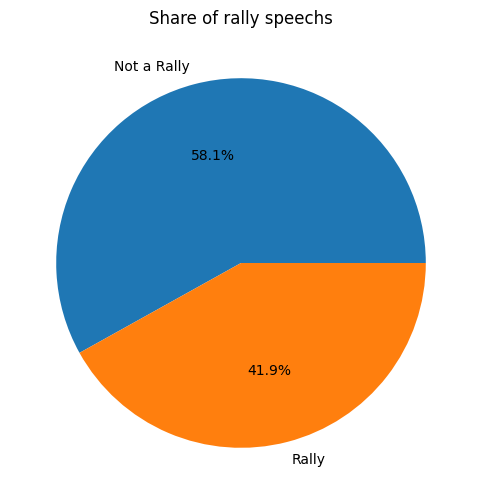

In [17]:
plt.figure(figsize=(6,6))
plt.subplot(111)

number=df_speeches["Is_Rally"].value_counts()

plt.pie(number,labels=["Not a Rally", "Rally"], autopct="%1.1f%%")

plt.title("Share of rally speechs")

plt.show()

Both rally speech and non-rally speeeches have simillar proportions in the dataset

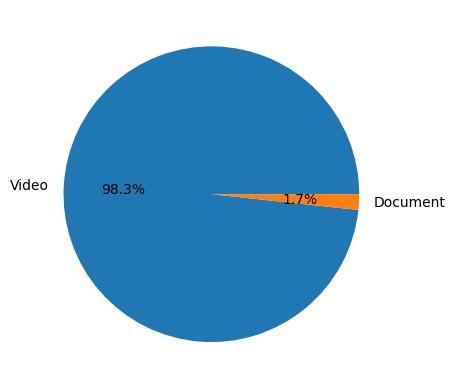

In [18]:
plt.figure()
count_type=df_speeches["Type"].value_counts()
plt.pie(count_type, labels=count_type.index, autopct="%1.1f%%")
plt.show()

Almost all records are videos

In [19]:

df_speeches["Location"]

0          Freeland
1      Fayetteville
2        Washington
3         Pensacola
4        Washington
           ...     
818    Grand Rapids
819       Green Bay
820      Washington
821      Eau Claire
822      Rothschild
Name: Location, Length: 823, dtype: object

#### Word cloud of the state location

In [20]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


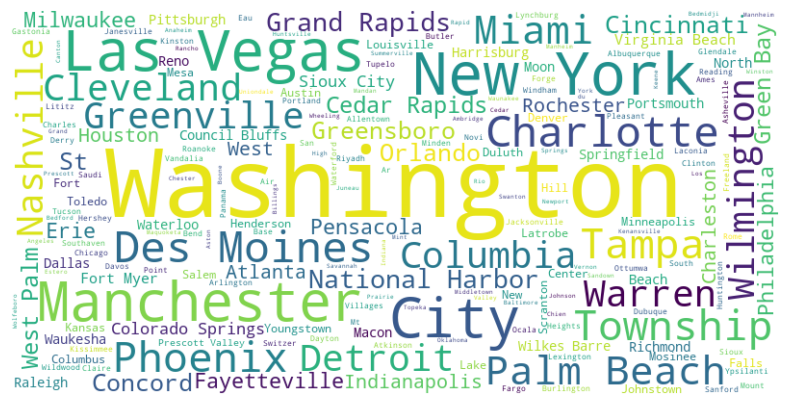

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

words = df_speeches["Location"].dropna () # To be carefull if there are missings values
text = " ".join(words)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)


plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


### Variation of number of meetings over time

In [22]:
df_speeches["Years"]=df_speeches["Date"].dt.year
df_speeches["Months"]=df_speeches["Date"].dt.month_name()
df_speeches["Days"]=df_speeches["Date"].dt.day_name()

In [23]:
df_speeches.head()

,Type,Location,Date,Title,Is_Rally,Years,Months,Days
0,Video,Freeland,2020-09-09,Donald Trump Holds a Campaign Rally in Freelan...,True,2020,September,Wednesday
1,Video,Fayetteville,2019-09-08,Donald Trump Holds a Political Rally in Fayett...,True,2019,September,Sunday
2,Video,Washington,2016-09-08,"Donald Trump in Washington, DC - September 9, ...",False,2016,September,Thursday
3,Document,Pensacola,2016-09-08,Donald Trump at the Pensacola Bay Center in Pe...,False,2016,September,Thursday
4,Video,Washington,2025-09-07,Donald Trump Addresses the Religious Liberty C...,False,2025,September,Sunday


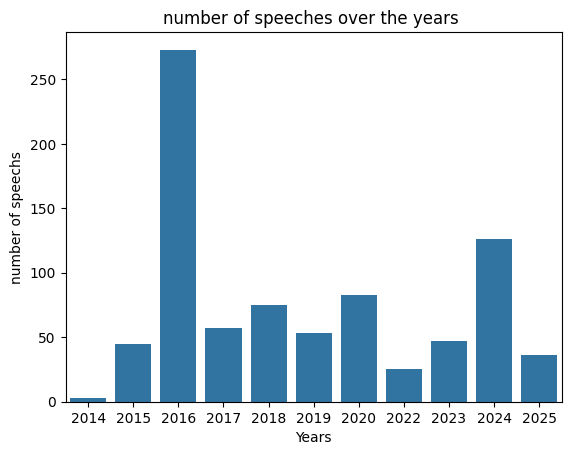

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.countplot(data=df_speeches, x="Years" )
plt.title("number of speeches over the years ")
plt.ylabel("number of speechs")

plt.show()

The most of meeting recorded has been doing in 2026. 

In [25]:
df_speeches["number_speechs"]=df_speeches.groupby(["Years", "Months"])["Title"].transform("count")

In [26]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
palette = sns.color_palette("tab20", n_colors=len(month_order))

In [27]:
df_speeches["Months"] = pd.Categorical(
    df_speeches["Months"],
    categories=month_order,
    ordered=True
)

C:\Users\Paulkengne\AppData\Local\Temp\ipykernel_19464\2591580822.py:3: UserWarning: The palette list has more values (12) than needed (11), which may not be intended.
  sns.pointplot(data=df_speeches, x="Months", y="number_speechs", hue="Years", color="skyblue", palette=palette)


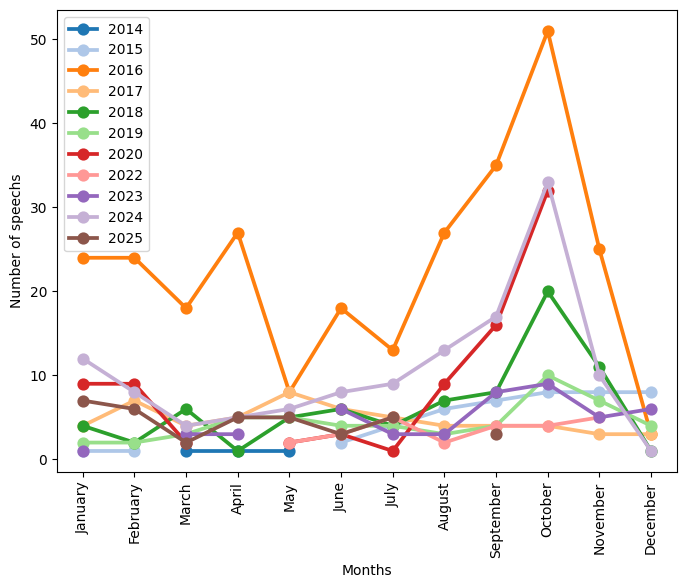

In [28]:
plt.figure(figsize=[8, 6])

sns.pointplot(data=df_speeches, x="Months", y="number_speechs", hue="Years", color="skyblue", palette=palette)
plt.ylabel("Number of speechs")
plt.legend(loc='upper left')

plt.xticks(rotation=90)
plt.show()

Except the year 2022 and 2017, the most of recorders refer to speechs delivered in october